# Rare Object Detection — Embedding Evaluation & Active Learning

This notebook evaluates the quality of learned embeddings across training runs that vary two hyperparameters:
- **Label fraction `f`**: fraction of the training set that carries morphological labels (0 = fully unsupervised, 1 = fully labelled)
- **Supervision weight `sw`**: relative weight of the supervised contrastive loss term

Retrieval quality is measured with **nDCG@10** per morphological class. The second half of the notebook runs **Protege** Gaussian-Process active learning on the resulting embeddings to efficiently surface rare/interesting radio galaxies.

All dependencies are installed and imported in the first code cell.

In [1]:
import re
import subprocess
import sys

# Install dependencies only if missing
def _install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

try:
    import astronomaly
except ModuleNotFoundError:
    _install("git+https://github.com/MichelleLochner/astronomaly.git")

try:
    import pyarrow
except ModuleNotFoundError:
    _install("pyarrow", "fastparquet", "numpy<2")

try:
    import ipywidgets as widgets
except ModuleNotFoundError:
    _install("ipywidgets")
    import ipywidgets as widgets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.path import Path as MPath
from pathlib import Path
from collections import defaultdict
from scipy.spatial.distance import cdist
import json
import hashlib

import astronomaly
from astronomaly.anomaly_detection import protege, human_loop_learning
from astronomaly.feature_extraction import shape_features as _sf
from astronomaly.anomaly_detection import isolation_forest as _isof
from astronomaly.base.base_dataset import Dataset as _AstroDataset

import umap as umap_lib
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest as _IsoForest

from IPython.display import display, clear_output

print("astronomaly version:", astronomaly.__version__)
print("numpy version:", np.__version__)
print("pyarrow version:", pyarrow.__version__)

%matplotlib inline

astronomaly version: 2.0
numpy version: 1.26.4
pyarrow version: 14.0.2


In [146]:
# ── Config ───────────────────────────────────────────────────────────────────
OUTPUTS_ROOT   = Path("/users/mbredber/p3_SUPLAT/outputs")
RUN_GLOB       = "run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f*_sw*"
EVAL_SPLIT     = "test"    # split used for nDCG evaluation
N_CLASSES      = 20        # number of label dimensions
NDCG_K         = 10        # k in nDCG@k

CSV_PATH        = "/users/mbredber/p3_SUPLAT/data/metadata/lotss_classifications_horton_et_al_2025_filtered.csv"
CUTOUT_DIR      = "/users/mbredber/p3_SUPLAT/data/raw/lotss_cutouts"
LABELS_NPY_PATH = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/labels_filtered.npy"
IMAGES_PATH     = "/users/mbredber/p3_SUPLAT/data/preprocessed/lotss/images_filtered.npy"

# ── Protege run selection ─────────────────────────────────────────────────────
F_LABEL            = 0   # label fraction of the run to analyse
SUPERVISION_WEIGHT = 1   # supervision weight of the run to analyse

_run_glob_specific = RUN_GLOB.replace("f*_sw*", f"f{F_LABEL}_sw{SUPERVISION_WEIGHT}_*")
_matching = sorted(OUTPUTS_ROOT.glob(_run_glob_specific))
assert len(_matching) == 1, (
    f"Expected exactly 1 run matching f={F_LABEL} sw={SUPERVISION_WEIGHT}, "
    f"found {len(_matching)}: {[r.name for r in _matching]}"
)
RUN_DIR = str(_matching[0] / "data")
print(f"RUN_DIR: {RUN_DIR}")

# ── Protege active-learning hyperparameters ───────────────────────────────────
APPLY_PCA = False      # Whether to apply PCA before Protege; set to False to use original features
INITIAL_STEPS  = 50   # number of initial random steps before the first Protege iteration; set to 0 to start with Protege immediately
STEPS_PER_ITER = 50   # number of steps to run between each Protege iteration; set to 0 to run all steps in one go
N_LABELS_TOTAL = 1000 # total number of labels to acquire (including initial random steps)
EPSILON        = 0    # Higher ε means more exploration, lower ε means more exploitation. Paper default is 2. Set to 0 to disable exploration and run pure exploitation (greedy acquisition of top-uncertainty samples).

RUN_DIR: /users/mbredber/p3_SUPLAT/outputs/run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f0_sw1_20260608_1411/data


## Retrieval Metric: nDCG@10

`nDCGk_avg` computes the mean nDCG@10 score for a given morphological class by treating every member of that class as a query in turn, ranking the remaining embeddings by cosine similarity, and scoring the ranked list against ground-truth labels. A score of 1.0 means all top-10 nearest neighbours belong to the correct class; 0.0 means none do.

In [147]:
def get_relevance(proj_in, lab_in, ref_class, mode="uniform"):
    relevance = np.zeros((proj_in.shape[0],))
    relevance[lab_in[:,ref_class]==True] = 1
    return relevance

def DCG(relevance_descending, k=10):
    num = 2**relevance_descending[:k] - 1
    den = np.log2(1+np.arange(1,k+1))
    return (num/den).sum()

def nDCG(relevance, sorting_cossim, k=10):
    IDCGk = DCG(np.sort(relevance)[::-1], k=k)
    DCGk = DCG(relevance[sorting_cossim], k=k)
    return DCGk/IDCGk

def nDCGk_avg(proj_in, lab_in, ref_class, k=20):
    mask_class = (lab_in[:,ref_class]==True)
    res = []
    for idx_ref in range(mask_class.sum()):
        reference_proj = proj_in[(lab_in[:,ref_class]==True)][idx_ref]
        mask_ref = (np.arange(proj_in.shape[0])==np.argwhere((lab_in[:,ref_class]==True))[idx_ref])
        proj_search = proj_in[~mask_ref]
        cos_d  = cdist(reference_proj[None,:], proj_search,   metric='cosine')
        sorting_cossim = np.argsort(cos_d.squeeze())
        relevance = get_relevance(proj_search, lab_in[~mask_ref], ref_class)
        nDCG_samp = nDCG(relevance, sorting_cossim, k=k)
        res.append(nDCG_samp)
    return (np.asarray(res).mean())

def nDCGk_avg_fast(proj_norm, lab_in, ref_class, k=20):
    """Vectorized nDCG@k. proj_norm must be L2-normalised (call once per run).
    Computes all query similarities in a single matrix multiply instead of
    one cdist call per class member."""
    mask      = lab_in[:, ref_class].astype(bool)
    class_idx = np.where(mask)[0]
    n_class   = len(class_idx)
    if n_class == 0:
        return np.nan

    # (n_class, N) cosine similarity via matmul; exclude self
    sim = proj_norm[class_idx] @ proj_norm.T          # (n_class, N)
    sim[np.arange(n_class), class_idx] = -np.inf

    # Relevance in ranked order for each query
    order      = np.argsort(-sim, axis=1)             # (n_class, N)
    rel_ranked = mask[order][:, :k].astype(float)     # (n_class, k)

    # DCG per query
    discount = 1.0 / np.log2(np.arange(2, k + 2))    # rank 1..k
    dcg      = (rel_ranked * discount).sum(axis=1)    # (n_class,)

    # IDCG is the same for every query: min(k, n_class-1) hits at top ranks
    n_rel = min(k, n_class - 1)
    idcg  = discount[:n_rel].sum() if n_rel > 0 else 0.0

    if idcg == 0:
        return 0.0
    return float((dcg / idcg).mean())

## Multi-Run Comparison

Loads test embeddings from every run directory matching `RUN_GLOB` (a string or list of glob patterns), computes per-class nDCG@10 for each, and collects the results into `run_results` for plotting.

In [148]:
_globs = [RUN_GLOB] if isinstance(RUN_GLOB, str) else RUN_GLOB
run_dirs = sorted({rd for g in _globs for rd in OUTPUTS_ROOT.glob(g)})

run_results = []
for rd in run_dirs:
    m = re.search(r'_f([\d.]+)_sw([\d.]+)_', rd.name)
    if not m:
        continue
    f_val    = float(m.group(1))
    sw_val   = float(m.group(2))
    data_dir = rd / "data"
    proj_path   = data_dir / f"{EVAL_SPLIT}_projections.npy"
    labels_path = data_dir / f"{EVAL_SPLIT}_labels.npy"
    if not proj_path.exists() or not labels_path.exists():
        print(f"  skipping {rd.name}  (missing {EVAL_SPLIT} projection files)")
        continue
    proj   = np.load(proj_path)
    labels = np.load(labels_path)
    # L2-normalise once; nDCGk_avg_fast uses a single matmul per class
    norms     = np.linalg.norm(proj, axis=1, keepdims=True)
    proj_norm = proj / np.maximum(norms, 1e-10)
    ndcg = [nDCGk_avg_fast(proj_norm, labels, c, k=NDCG_K) for c in range(N_CLASSES)]
    run_results.append(dict(name=rd.name, f=f_val, sw=sw_val, ndcg=ndcg))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})")

print(f"\nLoaded {len(run_results)} runs.")

  skipping run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f0.1_sw0.1_20260608_1425  (missing test projection files)
  loaded run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f0_sw1_20260608_1411  (f=0.0, sw=1.0)
  skipping run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f1_sw0.1_20260608_1430  (missing test projection files)

Loaded 1 runs.


### nDCG@10 Results Plot

Each point is one (run, class) pair. **Colour** encodes `sw` on a log-scaled viridis gradient (dark = low, bright = high). **Filled fraction of the circle** encodes `f`: an empty circle means no labels were used; a fully filled circle means all labels were used.

Saved: /users/mbredber/p3_SUPLAT/outputs/ndcg_per_class.pdf


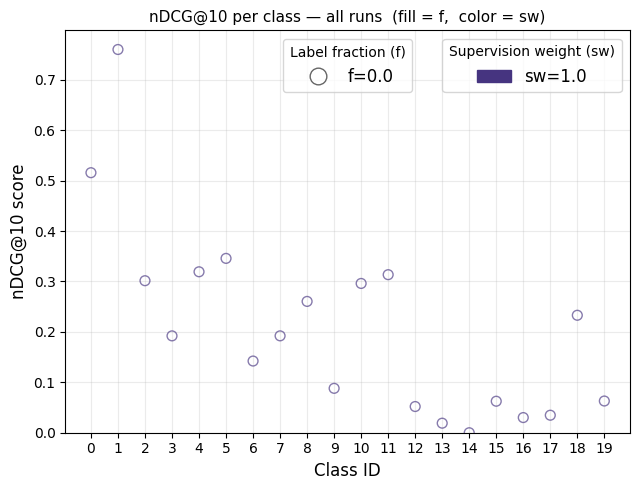

In [149]:
def pie_marker(fraction):
    """Wedge Path covering `fraction` of the unit circle, clockwise from 12 o'clock."""
    if fraction >= 1.0:
        n = 100
        t = np.linspace(0, 2 * np.pi, n, endpoint=False)
        verts = np.column_stack([np.cos(t), np.sin(t)])
        codes = [MPath.MOVETO] + [MPath.LINETO] * (n - 1) + [MPath.CLOSEPOLY]
        return MPath(np.vstack([verts, verts[:1]]), codes)
    n = 50
    t = np.linspace(np.pi / 2, np.pi / 2 - 2 * np.pi * fraction, n)
    verts = [(0.0, 0.0)] + list(zip(np.cos(t), np.sin(t))) + [(0.0, 0.0)]
    codes = [MPath.MOVETO] + [MPath.LINETO] * n + [MPath.CLOSEPOLY]
    return MPath(verts, codes)


f_vals  = sorted(set(r['f']  for r in run_results))
sw_vals = sorted(set(r['sw'] for r in run_results))

if not run_results:
    print("No run results found — skipping nDCG plot.")
else:
    cmap = plt.cm.viridis
    _sw_arr  = np.array(sw_vals, dtype=float)
    _sw_log  = np.log10(_sw_arr)
    _sw_norm = (_sw_log - _sw_log.min()) / (_sw_log.max() - _sw_log.min() + 1e-9)
    sw_color = {sw: cmap(0.15 + 0.70 * v) for sw, v in zip(sw_vals, _sw_norm)}

    fig, ax = plt.subplots(figsize=(6.5, 5))
    x = np.arange(N_CLASSES)
    S, ALPHA = 50, 0.65

    for r in run_results:
        color = sw_color[r['sw']]
        ax.scatter(x, r['ndcg'], facecolors='none', edgecolors=[color] * N_CLASSES,
                   marker='o', s=S, linewidths=1.0, zorder=2, alpha=ALPHA)
        if r['f'] > 0:
            ax.scatter(x, r['ndcg'], color=color, marker=pie_marker(r['f']),
                       s=S, linewidths=0, zorder=3, alpha=ALPHA)

    ax.set_xlabel("Class ID", fontsize=12)
    ax.set_ylabel("nDCG@10 score", fontsize=12)
    ax.set_ylim([0, None])
    ax.set_xticks(x)
    ax.tick_params(labelsize=10)
    ax.grid(True, alpha=0.25)

    LFS, LMS = 12, 12  # legend fontsize, markersize
    grey = (0.4, 0.4, 0.4)

    f_handles = []
    for f in f_vals:
        if f == 0:
            h = mlines.Line2D([], [], linestyle='None', marker='o', markersize=LMS,
                              markerfacecolor='none', markeredgecolor=grey,
                              markeredgewidth=1.0, label=f'f={f}')
        else:
            h = mlines.Line2D([], [], linestyle='None', marker=pie_marker(f), markersize=LMS,
                              markerfacecolor=grey, markeredgecolor='none', label=f'f={f}')
        f_handles.append(h)

    sw_handles = [
        mpatches.Patch(color=sw_color[sw], label=f'sw={sw}')
        for sw in sw_vals
    ]

    # Stack both legends at upper right
    leg_sw = ax.legend(handles=sw_handles, title='Supervision weight (sw)',
                       loc='upper right', bbox_to_anchor=(1.0, 1.0),
                       framealpha=0.8, fontsize=LFS)
    ax.add_artist(leg_sw)
    ax.legend(handles=f_handles, title='Label fraction (f)',
              loc='upper center', framealpha=0.8, fontsize=LFS)

    ax.set_title("nDCG@10 per class — all runs  (fill = f,  color = sw)", fontsize=11)
    plt.tight_layout()

    _pdf_path = Path(OUTPUTS_ROOT) / "ndcg_per_class.pdf"
    fig.savefig(_pdf_path, bbox_inches="tight")
    print(f"Saved: {_pdf_path}")

    plt.show()

## Class Index Mapping

Based on the LoTSS classifications (Horton et al. 2025), the 20-dimensional
label vector corresponds to the following classes:

| Index | Column          | Classification       | Type        | N sources |
|-------|-----------------|----------------------|-------------|-----------|
| 0     | `fri`           | FRI                  | Initial     | 2992      |
| 1     | `frii`          | FRII                 | Initial     | 6231      |
| 2     | `hybrid`        | Hybrids              | Initial     | 966       |
| 3     | `spiral`        | Spirals              | Initial     | 234       |
| 4     | `relaxed`       | Relaxed doubles      | Initial     | 440       |
| 5     | `cshaped`       | C-curvature          | Morphology  | 2379      |
| 6     | `sshaped`       | S-curvature          | Morphology  | 1082      |
| 7     | `misaligned`    | Misalignment         | Morphology  | 1287      |
| 8     | `wings`         | Wings                | Morphology  | 1564      |
| 9     | `xshaped`       | X-shaped             | Morphology  | 179       |
| 10    | `straight`      | Straight jets        | Morphology  | 358       |
| 11    | `multihotspots` | Multiple hotspots    | Morphology  | 2040      |
| 12    | `continuous`    | Continuous jets      | Morphology  | 337       |
| 13    | `banding`       | Banding              | Morphology  | 133       |
| 14    | `onesided`      | One-sided            | Morphology  | 23        |
| 15    | `restarted`     | Restarted            | Morphology  | 193       |
| 16    | `cluster`       | Cluster              | Environment | 72        |
| 17    | `merger`        | Merger               | Environment | 63        |
| 18    | `diffuse`       | Diffuse emission     | Environment | 111       |
| 19    | `unknown`       | Unknown              | Environment | 126       |

### Protege interest scoring

Each source is assigned the score of its most interesting label (multi-label sources take the highest applicable score).
Counts are from the full 7596-row dataset (`labels_filtered.npy`), before any train/val/test split.
Positives (score ≥ 3): **1303** (17.2%).

| Score | Label(s) | Count | % |
|-------|----------|-------|---|
| 4 | `xshaped`, `unknown`, `cluster`, `merger` | 285 | 3.8% |
| 3 | `diffuse`, `sshaped`, `spiral` | 1018 | 13.4% |
| 2 | `restarted`, `onesided`, `banding`, `cshaped`, `wings`, `misaligned`, `multihotspots`, `relaxed` | 3480 | 45.8% |
| 1 | `fri`, `frii`, `hybrid`, `straight`, `continuous`, (none of the above) | 2813 | 37.0% |
| **Total** | | **7596** | **100%** |

In [150]:
LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]  # must match the column order used when labels_filtered.npy was saved

SCORE_4 = ["xshaped", "unknown", "cluster", "merger"]
SCORE_3 = ["diffuse", "sshaped", "spiral"]
SCORE_2 = ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "multihotspots", "relaxed"]
SCORE_1 = ["fri", "frii", "hybrid", "straight", "continuous"]

POSITIVE_THRESHOLD = 3     # sources with human_label >= this are "interesting"

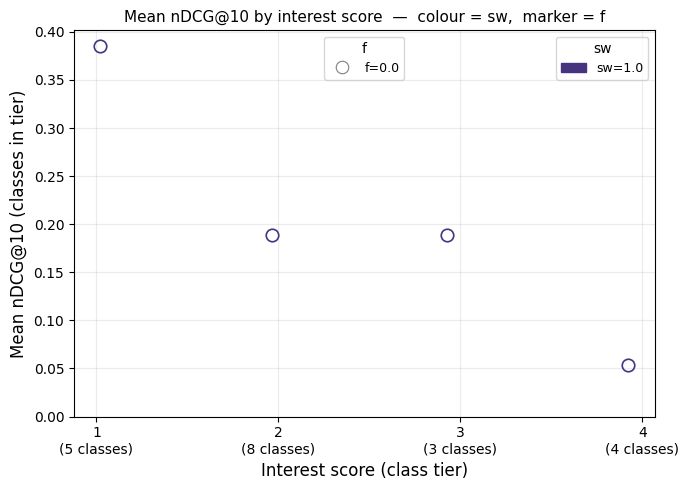

In [151]:
# ── Average nDCG@10 by interest score and (f, sw) combination ────────────────

# Map class index → interest score using the same tier definitions as Protege config
_LABEL_COLS = [
    "fri", "frii", "hybrid", "spiral", "relaxed",
    "cshaped", "sshaped", "misaligned", "wings", "xshaped",
    "straight", "multihotspots", "continuous", "banding", "onesided",
    "restarted", "cluster", "merger", "diffuse", "unknown",
]
_SCORE_MAP = {col: 1 for col in _LABEL_COLS}
for col in ["xshaped", "unknown", "cluster", "merger"]:
    _SCORE_MAP[col] = 4
for col in ["diffuse", "sshaped", "spiral"]:
    _SCORE_MAP[col] = 3
for col in ["restarted", "onesided", "banding", "cshaped", "wings", "misaligned", "multihotspots", "relaxed"]:
    _SCORE_MAP[col] = 2
_class_interest = np.array([_SCORE_MAP[c] for c in _LABEL_COLS])

interest_scores = sorted(set(_class_interest))
is_indices = {s: np.where(_class_interest == s)[0] for s in interest_scores}

fig, ax = plt.subplots(figsize=(7, 5))

runs_by_f = {}
for r in run_results:
    runs_by_f.setdefault(r['f'], []).append(r)

rng_jitter = np.random.default_rng(0)

for f_val in sorted(runs_by_f):
    marker = pie_marker(f_val) if f_val > 0 else 'o'
    for r in runs_by_f[f_val]:
        c = sw_color[r['sw']]
        mkw = dict(markerfacecolor='none', markeredgecolor=c, markeredgewidth=1.2) if f_val == 0 \
              else dict(markerfacecolor=c, markeredgecolor='none')
        for score in interest_scores:
            idxs = is_indices[score]
            vals = [r['ndcg'][i] for i in idxs if not np.isnan(r['ndcg'][i])]
            if not vals:
                continue
            y = np.mean(vals)
            jitter = rng_jitter.uniform(-0.08, 0.08)
            ax.plot(score + jitter, y, marker=marker, markersize=9,
                    linestyle='none', zorder=3, **mkw)

# Legends
f_handles = [
    mlines.Line2D([], [], color='grey', linewidth=0,
                  marker=pie_marker(f) if f > 0 else 'o',
                  markersize=9,
                  markerfacecolor='grey' if f > 0 else 'none',
                  markeredgecolor='grey',
                  markeredgewidth=0.8 if f == 0 else 0,
                  label=f'f={f}')
    for f in sorted(runs_by_f)
]
sw_handles = [mpatches.Patch(color=sw_color[sw], label=f'sw={sw}') for sw in sw_vals]

leg_sw = ax.legend(handles=sw_handles, title='sw', loc='upper right', fontsize=9, framealpha=0.8)
ax.add_artist(leg_sw)
ax.legend(handles=f_handles, title='f', loc='upper center', fontsize=9, framealpha=0.8)

# Annotate x-ticks with class count per tier
xtick_labels = [f'{s}\n({len(is_indices[s])} classes)' for s in interest_scores]
ax.set_xticks(interest_scores)
ax.set_xticklabels(xtick_labels, fontsize=10)
ax.set_xlabel('Interest score (class tier)', fontsize=12)
ax.set_ylabel('Mean nDCG@10 (classes in tier)', fontsize=12)
ax.set_title('Mean nDCG@10 by interest score  —  colour = sw,  marker = f', fontsize=11)
ax.grid(True, alpha=0.25)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

## Protege Active Learning Integration

Uses the [astronomaly](https://github.com/MichelleLochner/astronomaly) library to run a Gaussian-Process active learner on the learned embeddings. The GP iteratively selects the most informative unlabelled sources via an acquisition function, simulates a human labelling step using ground-truth morphology scores, and updates the model — surfacing rare/interesting sources far more efficiently than random inspection.

Results from each single-run execution are persisted to `protege/` under a filename encoding `EPSILON` and `N_LABELS_TOTAL`. The recall-curve cell automatically overlays all saved runs with different `EPSILON` values, so epsilon sweeps can be compared visually without re-running everything.

### Load Embeddings and Morphology Labels

Load the split's projection embeddings and positional row indices, join to the source catalogue CSV to recover `Source_Name` and per-class morphology flags, and convert the multi-label flags into a 1–5 human-interest score (5 = rarest/most exotic morphology).

In [152]:
RUN_DIR_ = Path(RUN_DIR)

# ── Load projections + indices (handles f=0, f=1, and mixed 0<f<1) ──────────
# For 0<f<1: train_projections.npy is labelled-only; combine with unlabelled.
# For f=0 or f=1: train_projections.npy already covers all train sources.
_lab_proj        = np.load(RUN_DIR_ / "labelled_train_projections.npy")
_lab_idx         = np.load(RUN_DIR_ / "labelled_train_idx.npy")
_unlab_idx       = np.load(RUN_DIR_ / "unlabelled_train_idx.npy")
_unlab_proj_path = RUN_DIR_ / "unlabelled_train_projections.npy"

if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    projections = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    idx_arr     = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0: all sources are unlabelled
    projections = _lab_proj
    idx_arr     = _unlab_idx
else:                       # f=1: all sources are labelled
    projections = _lab_proj
    idx_arr     = _lab_idx

print(f"projections: {projections.shape}  idx_arr: {idx_arr.shape}")
print(f"idx_arr max value: {idx_arr.max()}")
print(f"idx_arr min value: {idx_arr.min()}")
print(f"Any idx >= 7596 (npy length): {(idx_arr >= 7596).sum()}")

# Load CSV only for Source_Name — row order matches images_filtered.npy for the first 7596 rows
csv_df       = pd.read_csv(CSV_PATH)
source_names = csv_df.iloc[idx_arr]["Source_Name"].values

features_df = pd.DataFrame(projections, index=source_names)

# ── Load labels from the aligned .npy file (NOT the CSV) ──────────────────
# images_filtered.npy and labels_filtered.npy are row-aligned companions.
# The CSV has 7607 rows vs 7596 in the npy files — they are NOT aligned,
# so csv_df.iloc[idx_arr] gives wrong labels. Use labels_filtered.npy instead.

labels_all   = np.load(LABELS_NPY_PATH)       # shape (7596, 20)
labels_split = labels_all[idx_arr]            # shape (N_split, 20) — aligned with projections

# Build a DataFrame for convenient column access
labels_npy_df = pd.DataFrame(labels_split.astype(bool), columns=LABEL_COLS)

# Build human_label (1–4) from tier scoring
TIERS = [(4, SCORE_4), (3, SCORE_3), (2, SCORE_2)]
human_labels = np.ones(len(labels_npy_df), dtype=int)
for score_val, cols in reversed(TIERS):
    mask = labels_npy_df[cols].any(axis=1).values
    human_labels[mask] = score_val

labels_df = pd.DataFrame({"human_label": human_labels}, index=source_names)

print("human_label distribution:")
print(pd.Series(human_labels).value_counts().sort_index())
binary_label = (human_labels >= 4).astype(int)
print(f"\nPositives (score≥4): {binary_label.sum()}  |  Negatives: {(binary_label==0).sum()}")

# ── Load test projections + labels (needed for UMAP and Protege eval) ────────
_test_idx   = np.load(RUN_DIR_ / "test_idx.npy")
_test_proj  = np.load(RUN_DIR_ / "test_projections.npy")
_test_names = csv_df.iloc[_test_idx]["Source_Name"].values

_test_labels_raw = labels_all[_test_idx]
_test_labels_df  = pd.DataFrame(_test_labels_raw.astype(bool), columns=LABEL_COLS)
_test_human      = np.ones(len(_test_labels_df), dtype=int)
for _sv, _cols in reversed(TIERS):
    _test_human[_test_labels_df[_cols].any(axis=1).values] = _sv

labels_df = pd.concat([
    labels_df,
    pd.DataFrame({"human_label": _test_human}, index=_test_names),
])

# Combined train + test arrays (used by UMAP and PCA cells)
n_train   = len(projections)
all_proj  = np.concatenate([projections, _test_proj], axis=0)
all_names = np.concatenate([source_names, _test_names])

print(f"\nTest sources: {len(_test_idx)}  |  Total (train+test): {len(all_proj)}")

projections: (5317, 50)  idx_arr: (5317,)
idx_arr max value: 7595
idx_arr min value: 1
Any idx >= 7596 (npy length): 0
human_label distribution:
1    1959
2    2438
3     725
4     195
Name: count, dtype: int64

Positives (score≥4): 195  |  Negatives: 5122

Test sources: 2279  |  Total (train+test): 7596


### Image Gallery

Shows 5 example images per interest score (1–4) to give a visual intuition for what each tier looks like.

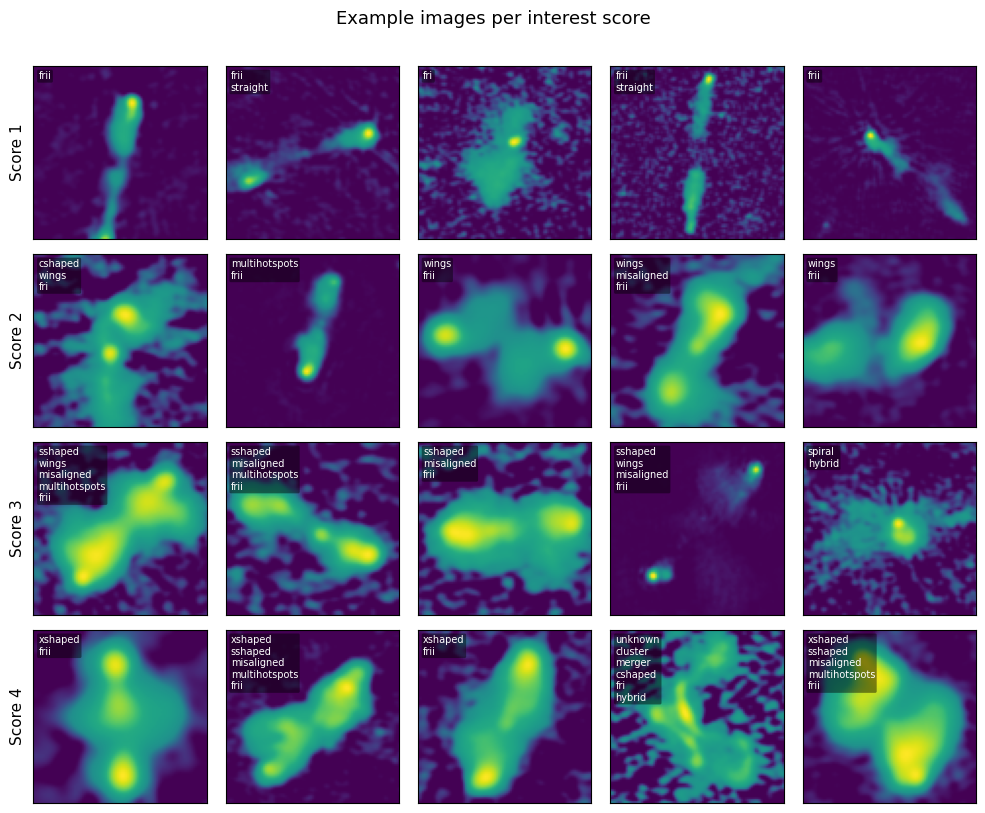

In [153]:
# Show 5 example images for each interest score (1–4)
images_all = np.load(IMAGES_PATH)
images = images_all[idx_arr]  # align with current split

ALL_MORPH_COLS = SCORE_4 + SCORE_3 + SCORE_2 + SCORE_1

N_EXAMPLES = 5
scores = [1, 2, 3, 4]
rng = np.random.default_rng(42)

fig, axes = plt.subplots(len(scores), N_EXAMPLES, figsize=(N_EXAMPLES * 2, len(scores) * 2))

for row, score in enumerate(scores):
    idxs = np.where(human_labels == score)[0]
    chosen = rng.choice(idxs, size=min(N_EXAMPLES, len(idxs)), replace=False)
    for col in range(N_EXAMPLES):
        ax = axes[row, col]
        if col < len(chosen):
            img = images[chosen[col]]
            if img.ndim == 3:
                img = img[0]  # take first channel if multi-channel
            ax.imshow(img, cmap='viridis', origin='lower')
            # Class labels: all True morphology columns for this source
            row_data = labels_npy_df.iloc[chosen[col]]
            active = [c for c in ALL_MORPH_COLS if row_data.get(c, False)]
            label_str = "\n".join(active) if active else "none"
            ax.text(0.03, 0.97, label_str, transform=ax.transAxes,
                    fontsize=7, color="white", va="top", ha="left",
                    bbox=dict(boxstyle="round,pad=0.15", fc="black", alpha=0.45, lw=0))
        else:
            ax.axis('off')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(f"Score {score}", fontsize=11, labelpad=6)

fig.suptitle("Example images per interest score", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### UMAP Projection

2-D UMAP of all sources (train + test), coloured by interest score. Cached to `umap_all_coords.npy` in the run directory for fast reloading.

Loaded UMAP from cache (7596 sources)


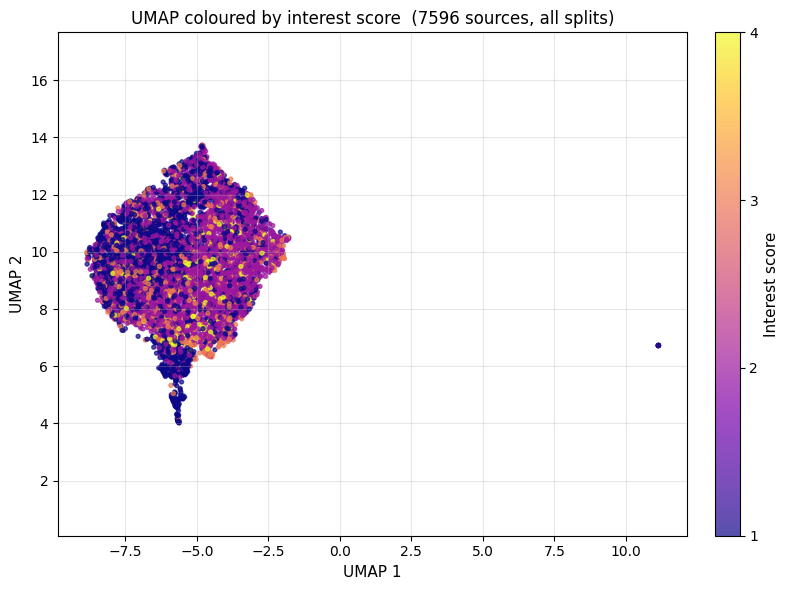

In [154]:
# UMAP is fitted on all sources (train + test) to match the training-script output.
_umap_cache = Path(RUN_DIR) / "umap_all_coords.npy"
_all_human_labels = np.concatenate([human_labels, _test_human])

if _umap_cache.exists() and np.load(_umap_cache).shape[0] == all_proj.shape[0]:
    _emb2d = np.load(_umap_cache)
    print(f"Loaded UMAP from cache ({len(_emb2d)} sources)")
else:
    print(f"Fitting UMAP on {all_proj.shape[0]} sources...")
    _reducer = umap_lib.UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42)
    _emb2d = _reducer.fit_transform(all_proj)
    np.save(_umap_cache, _emb2d)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    _emb2d[:, 0], _emb2d[:, 1],
    c=_all_human_labels, cmap='plasma',
    s=8, alpha=0.7, vmin=1, vmax=4,
)
cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Interest score', fontsize=11)
cbar.set_ticks([1, 2, 3, 4])
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.set_aspect('equal', adjustable='datalim')
ax.grid(True, alpha=0.3)
ax.set_title(f'UMAP coloured by interest score  ({all_proj.shape[0]} sources, all splits)',
             fontsize=12)
plt.tight_layout()
plt.show()

### KNN Nearest-Neighbour Gallery

For each SCORE_4 class, picks one random member as a query and shows its 8 nearest neighbours in embedding space. A yellow border on the centre image marks the query; neighbours are ranked by cosine distance.

/tmp/ipykernel_118917/566151639.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


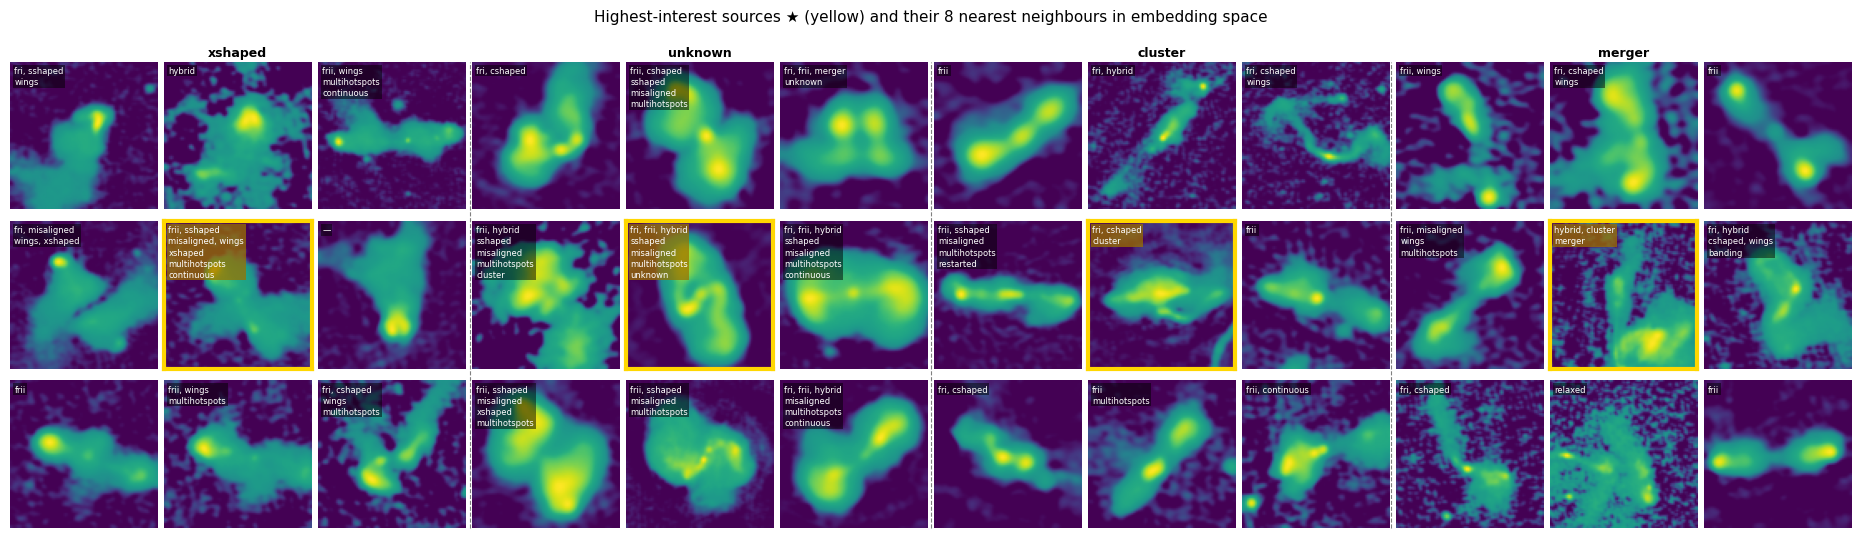

In [155]:
# =============================================================================
# KNN Gallery — highest-interest sources (SCORE_4 classes)
# Centre cell (yellow border) = query image (one random example per class).
# Surrounding 8 cells = nearest neighbours in embedding space.
# =============================================================================
KNN_SEED = 42

def _wrap_label(names, max_chars=18):
    lines, cur = [], ''
    for p in names:
        cand = f'{cur}, {p}' if cur else p
        if len(cand) > max_chars and cur:
            lines.append(cur); cur = p
        else:
            cur = cand
    if cur: lines.append(cur)
    return '\n'.join(lines)

rng_knn = np.random.default_rng(KNN_SEED)

nn_model = NearestNeighbors(n_neighbors=9, metric='euclidean').fit(projections)

# One random query per SCORE_4 class
queries = []
for cls in SCORE_4:
    candidates = np.where(labels_npy_df[cls].values)[0]
    if len(candidates) == 0:
        continue
    idx = rng_knn.choice(candidates)
    queries.append((cls, idx))

N_queries = len(queries)
cell_size  = 1.6
left_mar, right_mar, top_mar, bottom_mar = 0.02, 0.02, 0.10, 0.02

fig, axes = plt.subplots(
    3, 3 * N_queries,
    figsize=(cell_size * 3 * N_queries, cell_size * 3 + 0.5),
    gridspec_kw={'wspace': 0.03, 'hspace': 0.08},
)
fig.subplots_adjust(left=left_mar, right=1 - right_mar,
                    top=1 - top_mar, bottom=bottom_mar)

_, knn_all = nn_model.kneighbors(projections[[idx for _, idx in queries]])

for qi, (cls, q_idx) in enumerate(queries):
    neighbours = [i for i in knn_all[qi] if i != q_idx][:8]
    col_offset = qi * 3

    grid = [neighbours[0], neighbours[1], neighbours[2],
            neighbours[3], None,          neighbours[4],
            neighbours[5], neighbours[6], neighbours[7]]

    q_img = images[q_idx]
    if q_img.ndim == 3: q_img = q_img[0]

    # Title above the centre column
    axes[0, col_offset + 1].set_title(cls, fontsize=9, fontweight='bold', pad=4)

    for flat_pos, real_idx in enumerate(grid):
        row     = flat_pos // 3
        col_pos = col_offset + (flat_pos % 3)
        ax      = axes[row, col_pos]

        if real_idx is None:
            # Centre: query image with yellow border
            ax.imshow(q_img, cmap='viridis', origin='lower')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_edgecolor('gold')
                spine.set_linewidth(3)
            ax.axis('on'); ax.set_xticks([]); ax.set_yticks([])
            q_active = [c for c in LABEL_COLS if labels_npy_df.iloc[q_idx][c]]
            ax.text(0.03, 0.97, _wrap_label(q_active),
                    transform=ax.transAxes, fontsize=6, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='#9a7200', alpha=0.75, pad=1, linewidth=0))
        else:
            nb_img = images[real_idx]
            if nb_img.ndim == 3: nb_img = nb_img[0]
            ax.imshow(nb_img, cmap='viridis', origin='lower')
            ax.axis('off')
            nb_active = [c for c in LABEL_COLS if labels_npy_df.iloc[real_idx][c]]
            ax.text(0.03, 0.97, _wrap_label(nb_active) if nb_active else '—',
                    transform=ax.transAxes, fontsize=6, color='white',
                    va='top', ha='left', linespacing=1.3,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1, linewidth=0))

    if qi < N_queries - 1:
        plot_width = 1 - left_mar - right_mar
        x_sep = left_mar + plot_width * (col_offset + 3) / (3 * N_queries)
        fig.add_artist(plt.matplotlib.lines.Line2D(
            [x_sep, x_sep], [bottom_mar, 1 - top_mar],
            transform=fig.transFigure,
            color='grey', linewidth=0.8, linestyle='--', zorder=10,
        ))

fig.suptitle('Highest-interest sources ★ (yellow) and their 8 nearest neighbours in embedding space',
             fontsize=11, y=0.999)
plt.tight_layout()
plt.show()


### Gaussian Process Active Learning Loop

Defines `run_GP_active_learning`, which wraps the Protege GP pipeline: it seeds `initial_steps` sources, then iteratively selects the highest-acquisition unlabelled sources, reveals ground-truth labels, and re-fits the GP until `N_labels` sources have been labelled.

The cell also standardises the full projection matrix with `StandardScaler` so the GP kernel operates on unit-variance features.

In [156]:
def run_GP_active_learning(features, labels, input_anomaly_scores, output_dir,
                           steps=10, initial_steps=None, N_labels=100, epsilon=0.5,
                           labelable_index=None):
    anomaly_scores = input_anomaly_scores.copy()
    anomaly_scores['human_label'] = [-1] * len(anomaly_scores)
    pipeline_active_learning = protege.GaussianProcess(
        features, force_rerun=True, output_dir=output_dir, ei_tradeoff=epsilon)

    def _pick_unlabeled(df, n):
        mask = df['human_label'] == -1
        if labelable_index is not None:
            mask = mask & df.index.isin(labelable_index)
        return df[mask].index[:n]

    if initial_steps is not None:
        anomaly_scores.sort_values('score', ascending=False, inplace=True)
        inds = _pick_unlabeled(anomaly_scores, initial_steps)
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    else:
        initial_steps = 0
    for i in range(initial_steps // steps, N_labels // steps):
        anomaly_scores.sort_values('acquisition', ascending=False, inplace=True)
        inds = _pick_unlabeled(anomaly_scores, steps)
        anomaly_scores.loc[inds, 'human_label'] = labels.loc[inds, 'human_label']
        features_with_labels = pipeline_active_learning.combine_data_frames(features, anomaly_scores)
        active_output = pipeline_active_learning.run(features_with_labels)
        anomaly_scores['trained_score'] = active_output['trained_score']
        anomaly_scores['acquisition']   = active_output['acquisition']
    return anomaly_scores, pipeline_active_learning


Embedding dim: 50d  (analysis PCA on first 50 components)
  Dims for 95% variance: 39
  Dims for 99% variance: 48
  Variance captured by 50 components: 1.000


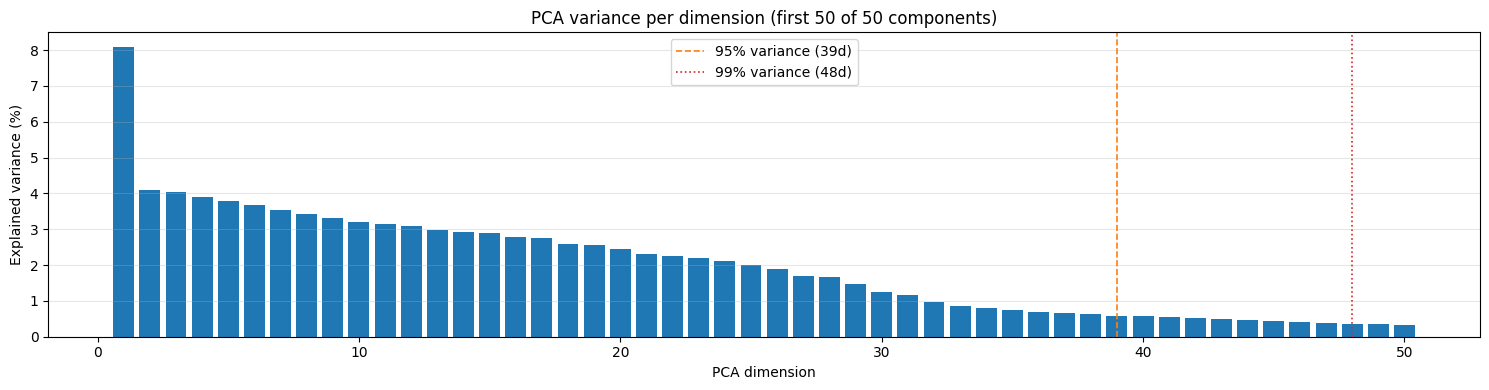


PCA not applied — using full 50d embeddings.
features_pca: (7596, 50)  (train=5317, test=2279)


In [157]:
# No scaling — PCA will be applied directly to the raw projections if enabled.
all_proj_scaled    = all_proj
projections_scaled = all_proj[:n_train]
test_proj_scaled   = all_proj[n_train:]

# Always fit a partial PCA for variance analysis (fast: only 128 components)
_n_analysis = min(128, all_proj.shape[1])
_pca_analysis = PCA(n_components=_n_analysis, random_state=42)
_pca_analysis.fit(all_proj_scaled)

_cumvar = np.cumsum(_pca_analysis.explained_variance_ratio_)
_n_95   = int(np.searchsorted(_cumvar, 0.95)) + 1 if _cumvar[-1] >= 0.95 else f">{_n_analysis}"
_n_99   = int(np.searchsorted(_cumvar, 0.99)) + 1 if _cumvar[-1] >= 0.99 else f">{_n_analysis}"
print(f"Embedding dim: {all_proj.shape[1]}d  (analysis PCA on first {_n_analysis} components)")
print(f"  Dims for 95% variance: {_n_95}")
print(f"  Dims for 99% variance: {_n_99}")
print(f"  Variance captured by {_n_analysis} components: {_cumvar[-1]:.3f}")

fig, ax = plt.subplots(figsize=(max(6, _n_analysis * 0.3), 4))
ax.bar(np.arange(1, _n_analysis + 1), _pca_analysis.explained_variance_ratio_ * 100, color="tab:blue")
if isinstance(_n_95, int):
    ax.axvline(_n_95, color="tab:orange", linestyle="--", linewidth=1.2, label=f"95% variance ({_n_95}d)")
if isinstance(_n_99, int):
    ax.axvline(_n_99, color="tab:red",    linestyle=":",  linewidth=1.2, label=f"99% variance ({_n_99}d)")
ax.set_xlabel("PCA dimension")
ax.set_ylabel("Explained variance (%)")
ax.set_title(f"PCA variance per dimension (first {_n_analysis} of {all_proj.shape[1]} components)")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

if APPLY_PCA:
    pca = PCA(n_components=0.95, random_state=42)
    projections_pca  = pca.fit_transform(projections_scaled)
    test_proj_pca    = pca.transform(test_proj_scaled)
    all_proj_pca     = np.concatenate([projections_pca, test_proj_pca], axis=0)
    features_pca     = pd.DataFrame(all_proj_pca, index=all_names)
    print(f"\nPCA applied: {all_proj.shape[1]}d → {projections_pca.shape[1]}d "
          f"({pca.explained_variance_ratio_.sum():.3f} variance retained)")
else:
    features_pca = pd.DataFrame(all_proj_scaled, index=all_names)
    print(f"\nPCA not applied — using full {all_proj.shape[1]}d embeddings.")

print(f"features_pca: {features_pca.shape}  (train={n_train}, test={len(all_proj)-n_train})")
assert len(features_pca) == len(all_proj), "features_pca row count mismatch!"

In [158]:
assert len(features_pca) > n_train, (
    f"features_pca has {len(features_pca)} rows but n_train={n_train}: "
    "no test rows — re-run the PCA cell before this one.")
features_train = features_pca.iloc[:n_train]
features_test  = features_pca.iloc[n_train:]

_nb_protege_dir = Path(RUN_DIR) / "protege"
_nb_protege_dir.mkdir(parents=True, exist_ok=True)

# Seed with human_label values (1–4) for INITIAL_STEPS evenly-spaced sources
# so the GP starts with real signal rather than a degenerate binary 0/1 split.
anomaly_scores = pd.DataFrame({'score': np.zeros(len(features_pca))}, index=features_pca.index)
seed_positions = np.linspace(0, n_train - 1, INITIAL_STEPS, dtype=int)
seed_names = features_train.index[seed_positions]
anomaly_scores.loc[seed_names, 'score'] = labels_df.loc[seed_names, 'human_label'].values.astype(float)
n_positive_seeds = (labels_df.loc[seed_names, 'human_label'] >= POSITIVE_THRESHOLD).sum()
print(f"Seed set: {INITIAL_STEPS} sources, {n_positive_seeds} with score >= {POSITIVE_THRESHOLD} "
      f"({100 * n_positive_seeds / INITIAL_STEPS:.1f}%)")

# Normalise scores with ScoreConverter
score_converter = human_loop_learning.ScoreConverter(force_rerun=True, output_dir=str(_nb_protege_dir))
anomaly_scores = score_converter.run(anomaly_scores)

# ── Diagnostic: score distribution after ScoreConverter ──────────────────
print("\n── anomaly_scores after ScoreConverter ──")
print(anomaly_scores.describe())
print("\nscore value_counts (top 10):")
print(anomaly_scores['score'].value_counts().head(10))
n_unique = anomaly_scores['score'].nunique()
print(f"\nUnique score values: {n_unique}")
if n_unique == 1:
    print("WARNING: all scores are identical — GP has no signal to start from!")
score_min = anomaly_scores['score'].min()
score_max = anomaly_scores['score'].max()
print(f"\nScoreConverter output range: [{score_min:.4f}, {score_max:.4f}]")
if score_min == score_max:
    print("WARNING: ScoreConverter output is constant — GP has no gradient to learn from!")
elif score_max - score_min < 0.1:
    print("WARNING: ScoreConverter output range is very narrow — GP signal may be weak.")
# ─────────────────────────────────────────────────────────────────────────────

# Run transductive active learning: GP sees all sources (train + test),
# but labeling is restricted to train sources via labelable_index.
active_output, gp_pipeline = run_GP_active_learning(
    features_pca,                          # all sources — transductive GP
    labels_df.loc[features_train.index],   # labels available only for train
    anomaly_scores,
    output_dir=str(_nb_protege_dir),
    steps=STEPS_PER_ITER,
    initial_steps=INITIAL_STEPS,
    N_labels=N_LABELS_TOTAL,
    epsilon=EPSILON,
    labelable_index=features_train.index,  # restrict labeling to train sources
)
print("Active learning complete. Train labelled:", (active_output.loc[features_train.index, 'human_label'] > 0).sum())

# Test sources were scored inside the GP run (permanently unlabeled, human_label == -1)
test_output = active_output.loc[features_test.index, ['trained_score']].copy()
test_output['human_label'] = -2   # restore sentinel for downstream cell compat
print(f"Test scored: {len(test_output)}  score>=3: {(labels_df.loc[features_test.index,'human_label']>=3).sum()}")

# ── Persist this run's scores for epsilon comparison ─────────────────────────
_save_name = f"notebook_protege_eps{EPSILON:g}_q{N_LABELS_TOTAL}.parquet"
_save_path = _nb_protege_dir / _save_name

_train_save = active_output.loc[features_train.index, ['trained_score', 'acquisition', 'human_label']].copy()
_test_save  = test_output[['trained_score', 'human_label']].copy()
_test_save['acquisition'] = float('nan')
_combined = pd.concat([_train_save, _test_save])
_combined.to_parquet(_save_path)
print(f"Saved → {_save_path}")

Seed set: 50 sources, 7 with score >= 3 (14.0%)
/users/mbredber/p3_SUPLAT/outputs/anomaly_baselines/_ell_cache_42/astronomaly.log
Now switching to new log file:
/users/mbredber/p3_SUPLAT/outputs/run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f0_sw1_20260608_1411/data/protege/astronomaly.log
Running ScoreConverter ...
Running anomaly score rescaler...
Done! Time taken: 0.11631464958190918 s

── anomaly_scores after ScoreConverter ──
             score
count  7596.000000
mean      4.984531
std       0.210233
min       0.000000
25%       5.000000
50%       5.000000
75%       5.000000
max       5.000000

score value_counts (top 10):
score
5.00    7546
2.50      25
3.75      18
0.00       5
1.25       2
Name: count, dtype: int64

Unique score values: 5

ScoreConverter output range: [0.0000, 5.0000]
Running GaussianProcess ...
Running GP regression with 50 training points
Done! Time taken: 0.07006287574768066 s
Running GaussianProcess ...
Running GP regression with 100 training points

### Recall Curve

Ranks all queried-train and test sources by the GP's `trained_score` and plots cumulative interesting-source counts (label ≥ `POSITIVE_THRESHOLD`) on two side-by-side subplots. Baselines (complexity ranking, ellipses IsoForest, ellipses GP) are overlaid for comparison.

Each run is also saved to `protege/notebook_protege_eps{EPSILON}_q{N_LABELS_TOTAL}.parquet`. When Cell 29 runs, it scans that folder and overlays recall curves from any prior runs with a different `EPSILON`, enabling visual comparison across epsilon values without losing previous results.

In [159]:
# ── Compute / load baselines (complexity + ellipses) on the test set ─────────
# Ellipses IsoForest is fitted on ALL images (unsupervised, no split needed).
# Results are keyed by data_seed and hash-validated against test_idx.npy.

# data_seed: prefer protege_summary.json if available, else fall back to 42
_summary_path = Path(RUN_DIR) / "protege" / "protege_summary.json"
if _summary_path.exists():
    with open(_summary_path) as _fh:
        _data_seed = int(json.load(_fh).get("data_seed", 42))
else:
    _data_seed = 42

_test_idx_path  = Path(RUN_DIR) / "test_idx.npy"   # RUN_DIR already ends in /data
_hash           = hashlib.sha256(open(_test_idx_path, "rb").read()).hexdigest()
(OUTPUTS_ROOT / "anomaly_baselines").mkdir(parents=True, exist_ok=True)
_baselines_path = OUTPUTS_ROOT / "anomaly_baselines" / f"baselines_{_data_seed}.json"

# ── Always build _all_ell + _iforest (cached on disk via force_rerun=False) ──
_images_all = np.load(IMAGES_PATH).astype(np.float32) / 255.0
_ell_outdir = OUTPUTS_ROOT / "anomaly_baselines" / f"_ell_cache_{_data_seed}"
_ell_outdir.mkdir(exist_ok=True)

class _NumpyImageDataset(_AstroDataset):
    def __init__(self, images, output_dir, **kwargs):
        super().__init__(output_dir=output_dir, **kwargs)
        self.images   = images
        self.index    = [str(i) for i in range(len(images))]
        self.metadata = pd.DataFrame(index=self.index)
    def get_sample(self, idx):       return self.images[int(idx)]
    def get_display_data(self, idx): return {}

_ds  = _NumpyImageDataset(_images_all, output_dir=str(_ell_outdir), force_rerun=False)
_ext = _sf.EllipseFitFeatures(percentiles=[90, 70, 50, 0], channel=0,
                               output_dir=str(_ell_outdir), force_rerun=False)
_all_ell = _ext.run_on_dataset(_ds)

_iforest = _IsoForest(n_estimators=200, random_state=_data_seed)
_iforest.fit(_all_ell.values)

baselines = None
if _baselines_path.exists():
    with open(_baselines_path) as _fh:
        _cached = json.load(_fh)
    if _cached.get("test_idx_hash") == _hash:
        baselines = _cached
        print(f"Loaded baselines from cache  (seed={_data_seed}, n_eval={baselines['n_eval']})")

if baselines is None:
    print(f"Computing baselines (seed={_data_seed}) ...")
    # Reuse _test_idx and _test_human defined in cell 15
    _n_eval = len(_test_idx)
    _x      = np.arange(1, _n_eval + 1)
    _n_pos  = int((_test_human >= POSITIVE_THRESHOLD).sum())

    # ── Complexity: rank by featurecount descending ───────────────────────────
    _fc         = pd.read_csv(CSV_PATH)["featurecount"].values[_test_idx]
    _comp_order = np.argsort(_fc)[::-1]
    _cum_comp   = np.cumsum((_test_human[_comp_order] >= POSITIVE_THRESHOLD).astype(int))
    _auc_comp   = float(np.trapz(_cum_comp, _x) / (_n_eval * _n_pos)) if _n_pos > 0 else 0.0
    print(f"  complexity AUC={_auc_comp:.4f}")

    # ── Ellipses: score test sources with the already-fitted IsoForest ────────
    _test_ell   = _all_ell.iloc[_test_idx]
    _ell_scores = -_iforest.decision_function(_test_ell.values)
    _ell_order  = np.argsort(_ell_scores)[::-1]
    _cum_ell    = np.cumsum((_test_human[_ell_order] >= POSITIVE_THRESHOLD).astype(int))
    _auc_ell    = float(np.trapz(_cum_ell, _x) / (_n_eval * _n_pos)) if _n_pos > 0 else 0.0
    print(f"  ellipses  AUC={_auc_ell:.4f}")

    baselines = {
        "test_idx_hash": _hash, "data_seed": _data_seed,
        "n_eval": _n_eval, "n_pos": _n_pos,
        "complexity": {"recall": _cum_comp.tolist(), "x": _x.tolist(), "auc": _auc_comp},
        "ellipses":   {"recall": _cum_ell.tolist(),  "x": _x.tolist(), "auc": _auc_ell},
    }
    with open(_baselines_path, "w") as _fh:
        json.dump(baselines, _fh)
    print(f"Saved to {_baselines_path}")

# ── Correlation: featurecount vs positive label (test set) ───────────────────
_fc_all     = pd.read_csv(CSV_PATH)["featurecount"].values[_test_idx]
_pos_binary = (_test_human >= POSITIVE_THRESHOLD).astype(float)
_corr       = float(np.corrcoef(_fc_all.astype(float), _pos_binary)[0, 1])
print(f"featurecount/label correlation — test set ({len(_test_idx)} sources): r={_corr:.4f}")

# ── Ellipses GP ("neighbour score") from train_anomaly_baselines.py ──────────
_ell_base_dir = OUTPUTS_ROOT / f"anomaly_baseline_seed{_data_seed}" / "ellipses"
_ell_gp = None
if _ell_base_dir.exists():
    _src_names_test = _test_names
    _run_curves = []
    for _rp in sorted(_ell_base_dir.glob("run_*/protege_scores.parquet")):
        _df        = pd.read_parquet(_rp)
        _test_part = _df[_df["human_label"] == -2.0]
        common = [n for n in _src_names_test if n in _test_part.index]
        if len(common) < 0.9 * len(_src_names_test):
            continue  # split mismatch, skip
        _ranked = _test_part.loc[common].sort_values("trained_score", ascending=False)
        _tl     = pd.Series(_test_human, index=_src_names_test).loc[_ranked.index]
        _cum    = np.cumsum((_tl >= POSITIVE_THRESHOLD).astype(int).values)
        _run_curves.append(_cum)
    if _run_curves:
        _min_len  = min(len(c) for c in _run_curves)
        _mean_c   = np.array([c[:_min_len] for c in _run_curves]).mean(axis=0)
        _x_gp     = np.arange(1, _min_len + 1)
        _n_pos_bl = baselines["n_pos"]
        _auc_gp   = float(np.trapz(_mean_c, _x_gp) / (_min_len * _n_pos_bl)) if _n_pos_bl > 0 else 0.0
        _ell_gp   = {"recall": _mean_c.tolist(), "x": _x_gp.tolist(), "auc": _auc_gp,
                     "n_runs": len(_run_curves)}
        print(f"  ellipses GP AUC={_auc_gp:.4f}  ({len(_run_curves)} runs averaged)")

baselines["ellipses_gp"] = _ell_gp   # None if not available
with open(_baselines_path, "w") as _fh:
    json.dump(baselines, _fh)

/users/mbredber/p3_SUPLAT/outputs/run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f0_sw1_20260608_1411/data/protege/astronomaly.log
Now switching to new log file:
/users/mbredber/p3_SUPLAT/outputs/anomaly_baselines/_ell_cache_42/astronomaly.log


2026-06-08 14:41:11,246 - WARNING - Pipeline stage EllipseFitFeatures previously called with same arguments. Loading from file. Will only run for new samples. Use 'force_rerun=True' in init args to override this behavior.


Extracting features using EllipseFitFeatures ...


/users/mbredber/.venv/lib64/python3.11/site-packages/astronomaly/base/base_pipeline.py:347: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  output = pd.concat((self.previous_output, new_output))


Done! Time taken:  0.0745992660522461 s
Loaded baselines from cache  (seed=42, n_eval=2279)
featurecount/label correlation — test set (2279 sources): r=0.4376


featurecount/label correlation — queried train (1000 sources): r=0.3535
Saved recall curves → /users/mbredber/p3_SUPLAT/outputs/run_enb0_mlp_pd50_pond_lrconst_wd1e-4_lfull_e300_b256_f0_sw1_20260608_1411/figures/recall_curves_eps0_q1000.png


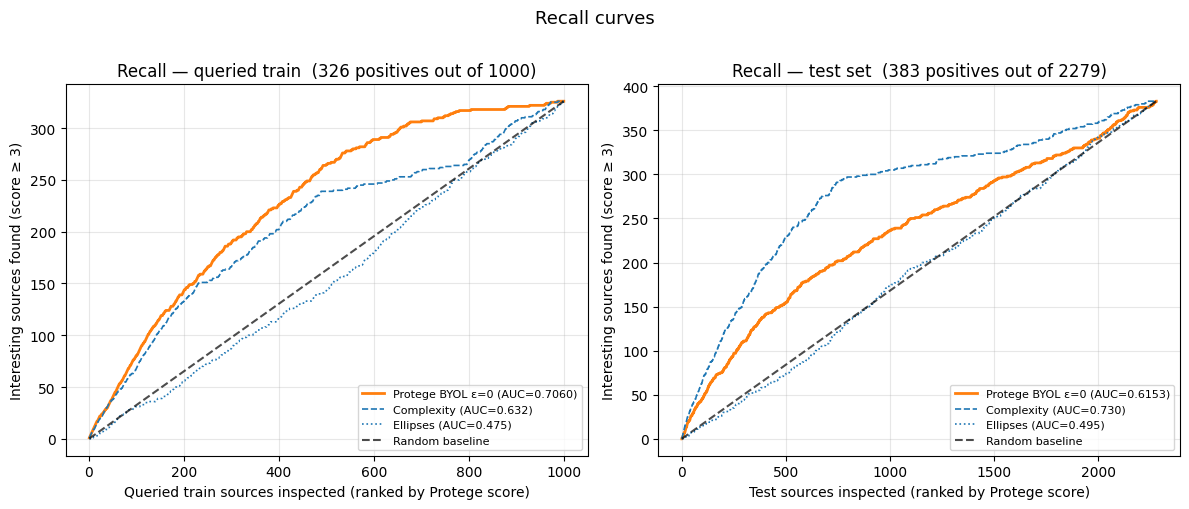

In [160]:
fig, (ax_tr, ax_te) = plt.subplots(1, 2, figsize=(12, 5))

# ── Load previously saved notebook runs for overlay ───────────────────────────
_protege_dir = Path(RUN_DIR) / "protege"
_saved_runs  = {}
if _protege_dir.exists():
    for _p in sorted(_protege_dir.glob(f"notebook_protege_eps*_q{N_LABELS_TOTAL}.parquet")):
        try:
            _eps_str = _p.stem.split("_eps")[1].split("_q")[0]
            _eps_val = float(_eps_str)
        except (IndexError, ValueError):
            continue
        if _eps_val == EPSILON:
            continue  # current run — already the main orange line
        _saved_runs[_eps_val] = pd.read_parquet(_p)

# Assign colours (tab10, skip index 1 = orange reserved for main Protege line)
_tab10  = plt.cm.tab10.colors
_ov_clr = [c for i, c in enumerate(_tab10) if i != 1]
_eps_color = {eps: _ov_clr[i % len(_ov_clr)]
              for i, eps in enumerate(sorted(_saved_runs))}

def _ordered_legend(ax, **kw):
    """Draw legend with order: Protege BYOL → Complexity → Ellipses → Random."""
    handles, labels = ax.get_legend_handles_labels()
    def _rank(label):
        if "Protege" in label:  return 0
        if "Complexity" in label: return 1
        if "Ellipses" in label:   return 2
        return 3
    pairs = sorted(zip(handles, labels), key=lambda hl: _rank(hl[1]))
    ax.legend([h for h, _ in pairs], [l for _, l in pairs], **kw)

# ══════════════════════════════════════════════════════════════════════════════
# LEFT — Queried train sources (analogous to Fig. 10, Lochner & Rudnick 2025)
# ══════════════════════════════════════════════════════════════════════════════
queried = active_output[active_output['human_label'] != -1].copy()
true_labels_train = labels_df.loc[queried.index, 'human_label']

n_queried   = len(queried)
n_pos_train = int((true_labels_train >= POSITIVE_THRESHOLD).sum())

ranked_q     = queried.sort_values('trained_score', ascending=False)
ranked_bin_q = (true_labels_train.loc[ranked_q.index] >= POSITIVE_THRESHOLD).astype(int).values
cumfound_q   = np.cumsum(ranked_bin_q)
x_q          = np.arange(1, n_queried + 1)
auc_q = float(np.trapz(cumfound_q, x_q) / (n_queried * n_pos_train)) if n_pos_train > 0 else 0.0

ax_tr.plot(x_q, cumfound_q, color="tab:orange", label=f'Protege BYOL ε={EPSILON:g} (AUC={auc_q:.4f})', linewidth=2)

# ── Overlay: other saved notebook runs (train) ────────────────────────────────
for _eps_val, _df_ov in sorted(_saved_runs.items()):
    _q_ov   = _df_ov[_df_ov['human_label'] > 0]
    _common = [n for n in _q_ov.index if n in labels_df.index]
    if not _common:
        continue
    _tl_ov  = labels_df.loc[_common, 'human_label']
    _rk_ov  = _q_ov.loc[_common].sort_values('trained_score', ascending=False)
    _n_q_ov = len(_rk_ov)
    _n_p_ov = int((_tl_ov >= POSITIVE_THRESHOLD).sum())
    _cum_ov = np.cumsum((_tl_ov.loc[_rk_ov.index] >= POSITIVE_THRESHOLD).astype(int).values)
    _x_ov   = np.arange(1, _n_q_ov + 1)
    _auc_ov = float(np.trapz(_cum_ov, _x_ov) / (_n_q_ov * _n_p_ov)) if _n_p_ov > 0 else 0.0
    ax_tr.plot(_x_ov, _cum_ov, color=_eps_color[_eps_val], linewidth=1.5,
               label=f'Protege BYOL ε={_eps_val:g} (AUC={_auc_ov:.4f})')

# Complexity baseline (train)
_csv_fc     = pd.read_csv(CSV_PATH).set_index("Source_Name")["featurecount"]
_q_fc       = _csv_fc.loc[queried.index].values
_comp_order = np.argsort(_q_fc)[::-1]
_bin_comp_q = (true_labels_train.values >= POSITIVE_THRESHOLD)[_comp_order]
_cum_comp_q = np.cumsum(_bin_comp_q)
_auc_comp_q = float(np.trapz(_cum_comp_q, x_q) / (n_queried * n_pos_train)) if n_pos_train > 0 else 0.0
ax_tr.plot(x_q, _cum_comp_q, color="tab:blue", linewidth=1.2, linestyle="--",
           label=f"Complexity (AUC={_auc_comp_q:.3f})")

_corr_q = float(np.corrcoef(_q_fc.astype(float),
                             (true_labels_train.values >= POSITIVE_THRESHOLD).astype(float))[0, 1])
print(f"featurecount/label correlation — queried train ({n_queried} sources): r={_corr_q:.4f}")

# Ellipses IsoForest baseline (train)
try:
    _name_to_split = {n: i for i, n in enumerate(all_names)}
    _q_split_pos   = np.array([_name_to_split[n] for n in queried.index])
    _q_global_idx  = idx_arr[_q_split_pos]
    _q_ell_feat    = _all_ell.iloc[_q_global_idx].values
    _q_ell_scores  = -_iforest.decision_function(_q_ell_feat)
    _ell_order_tr  = np.argsort(_q_ell_scores)[::-1]
    _bin_ell_q     = (true_labels_train.values >= POSITIVE_THRESHOLD)[_ell_order_tr]
    _cum_ell_q     = np.cumsum(_bin_ell_q)
    _x_ell_q       = np.arange(1, len(_cum_ell_q) + 1)
    _auc_ell_q     = float(np.trapz(_cum_ell_q, _x_ell_q) / (len(_cum_ell_q) * n_pos_train)) if n_pos_train > 0 else 0.0
    ax_tr.plot(_x_ell_q, _cum_ell_q, color="tab:blue", linewidth=1.2, linestyle=":",
               label=f"Ellipses (AUC={_auc_ell_q:.3f})")
except Exception as _e:
    print(f"Ellipses IsoForest train baseline skipped: {_e}")

# Ellipses GP baseline (train)
try:
    _ell_base_dir  = OUTPUTS_ROOT / f"anomaly_baseline_seed{_data_seed}" / "ellipses"
    _ell_gp_curves = []
    for _rp in sorted(_ell_base_dir.glob("run_*/protege_scores.parquet")):
        _df_ell    = pd.read_parquet(_rp)
        _train_ell = _df_ell[_df_ell["human_label"] != -2.0]
        common_q   = [n for n in queried.index if n in _train_ell.index]
        if len(common_q) < 5:
            continue
        _ell_ranked = _train_ell.loc[common_q].sort_values("trained_score", ascending=False)
        _ell_tl     = true_labels_train.loc[_ell_ranked.index]
        _ell_cum    = np.cumsum((_ell_tl >= POSITIVE_THRESHOLD).astype(int).values)
        _ell_gp_curves.append(_ell_cum)
    if _ell_gp_curves:
        _ml  = min(len(c) for c in _ell_gp_curves)
        _mc  = np.array([c[:_ml] for c in _ell_gp_curves]).mean(axis=0)
        _xgp = np.arange(1, _ml + 1)
        _agp = float(np.trapz(_mc, _xgp) / (_ml * n_pos_train)) if n_pos_train > 0 else 0.0
        ax_tr.plot(_xgp, _mc, color="tab:green", linewidth=1.2, linestyle=":",
                   label=f"Ellipses GP (AUC={_agp:.3f})")
except Exception:
    pass

ax_tr.plot(x_q, x_q * (n_pos_train / n_queried), 'k--', label='Random baseline', linewidth=1.5, alpha=0.7)

ax_tr.set_xlabel('Queried train sources inspected (ranked by Protege score)')
ax_tr.set_ylabel(f'Interesting sources found (score ≥ {POSITIVE_THRESHOLD})')
ax_tr.set_title(f'Recall — queried train  ({n_pos_train} positives out of {n_queried})')
_ordered_legend(ax_tr, fontsize=8, loc="lower right")
ax_tr.grid(True, alpha=0.3)

# ══════════════════════════════════════════════════════════════════════════════
# RIGHT — Test set
# ══════════════════════════════════════════════════════════════════════════════
true_labels = labels_df.loc[test_output.index, 'human_label']
n_eval      = len(test_output)
n_pos_total = int((true_labels >= POSITIVE_THRESHOLD).sum())

ranked_eval   = test_output.sort_values('trained_score', ascending=False)
ranked_binary = (true_labels.loc[ranked_eval.index] >= POSITIVE_THRESHOLD).astype(int).values
cumulative_found = np.cumsum(ranked_binary)
x_labels = np.arange(1, n_eval + 1)
auc = float(np.trapz(cumulative_found, x_labels) / (n_eval * n_pos_total)) if n_pos_total > 0 else 0.0

ax_te.plot(x_labels, cumulative_found, color="tab:orange", label=f'Protege BYOL ε={EPSILON:g} (AUC={auc:.4f})', linewidth=2)

# ── Overlay: other saved notebook runs (test) ─────────────────────────────────
for _eps_val, _df_ov in sorted(_saved_runs.items()):
    _t_ov   = _df_ov[_df_ov['human_label'] == -2]
    _common = [n for n in _t_ov.index if n in labels_df.index]
    if not _common:
        continue
    _tl_tov  = labels_df.loc[_common, 'human_label']
    _rk_tov  = _t_ov.loc[_common].sort_values('trained_score', ascending=False)
    _n_ev_ov = len(_rk_tov)
    _n_pt_ov = int((_tl_tov >= POSITIVE_THRESHOLD).sum())
    _cum_tov = np.cumsum((_tl_tov.loc[_rk_tov.index] >= POSITIVE_THRESHOLD).astype(int).values)
    _x_tov   = np.arange(1, _n_ev_ov + 1)
    _auc_tov = float(np.trapz(_cum_tov, _x_tov) / (_n_ev_ov * _n_pt_ov)) if _n_pt_ov > 0 else 0.0
    ax_te.plot(_x_tov, _cum_tov, color=_eps_color[_eps_val], linewidth=1.5,
               label=f'Protege BYOL ε={_eps_val:g} (AUC={_auc_tov:.4f})')

try:
    if baselines is not None:
        ax_te.plot(baselines["complexity"]["x"], baselines["complexity"]["recall"],
                   color="tab:blue", linewidth=1.2, linestyle="--",
                   label=f"Complexity (AUC={baselines['complexity']['auc']:.3f})")
        ax_te.plot(baselines["ellipses"]["x"], baselines["ellipses"]["recall"],
                   color="tab:blue", linewidth=1.2, linestyle=":",
                   label=f"Ellipses (AUC={baselines['ellipses']['auc']:.3f})")
        if baselines.get("ellipses_gp") is not None:
            _egp = baselines["ellipses_gp"]
            ax_te.plot(_egp["x"], _egp["recall"],
                       color="tab:green", linewidth=1.2, linestyle=":",
                       label=f"Ellipses GP (AUC={_egp['auc']:.3f})")
except NameError:
    pass

ax_te.plot(x_labels, x_labels * (n_pos_total / n_eval), 'k--', label='Random baseline', linewidth=1.5, alpha=0.7)

ax_te.set_xlabel('Test sources inspected (ranked by Protege score)')
ax_te.set_ylabel(f'Interesting sources found (score ≥ {POSITIVE_THRESHOLD})')
ax_te.set_title(f'Recall — test set  ({n_pos_total} positives out of {n_eval})')
_ordered_legend(ax_te, fontsize=8, loc="lower right")
ax_te.grid(True, alpha=0.3)

plt.suptitle('Recall curves', fontsize=13, y=1.01)
plt.tight_layout()
_figures_dir = Path(RUN_DIR).parent / "figures"
_figures_dir.mkdir(parents=True, exist_ok=True)
_recall_path = _figures_dir / f"recall_curves_eps{EPSILON:g}_q{N_LABELS_TOTAL}.png"
plt.savefig(_recall_path, dpi=150, bbox_inches="tight")
print(f"Saved recall curves → {_recall_path}")
plt.show()

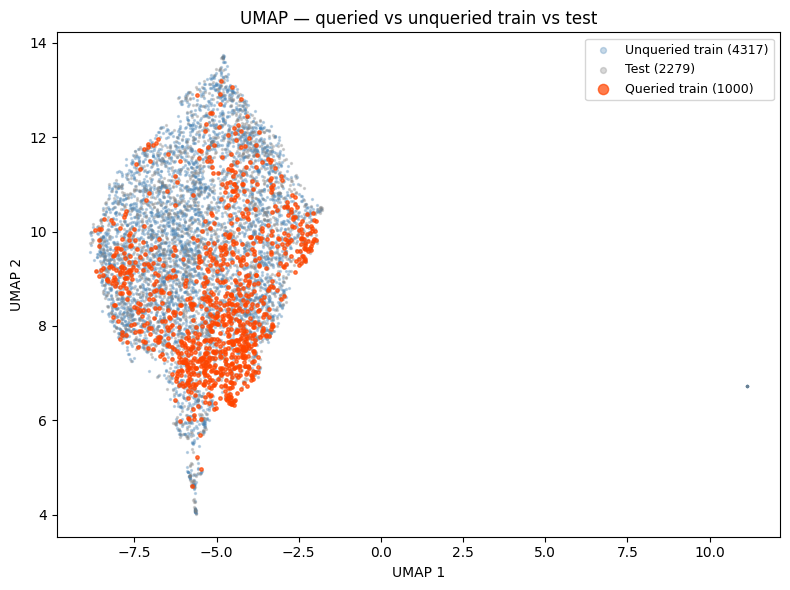

In [161]:
# ── UMAP: coverage of queried sources ──────────────────────────────────────
_queried_mask = active_output.loc[features_train.index, 'human_label'].values != -1

_emb_train = _emb2d[:n_train]
_emb_test  = _emb2d[n_train:]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(_emb_train[~_queried_mask, 0], _emb_train[~_queried_mask, 1],
           s=2, alpha=0.3, color='steelblue', label=f'Unqueried train ({(~_queried_mask).sum()})')
ax.scatter(_emb_test[:, 0], _emb_test[:, 1],
           s=2, alpha=0.3, color='gray', label=f'Test ({len(_emb_test)})')
ax.scatter(_emb_train[_queried_mask, 0], _emb_train[_queried_mask, 1],
           s=6, alpha=0.7, color='orangered', label=f'Queried train ({_queried_mask.sum()})')
ax.set_title('UMAP — queried vs unqueried train vs test')
ax.legend(markerscale=3, fontsize=9)
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
plt.tight_layout(); plt.show()


Mean NN distance  queried: 0.2592  random: 0.2412  ratio: 1.075
(ratio > 1 → queried set covers test space worse than a random sample of same size)


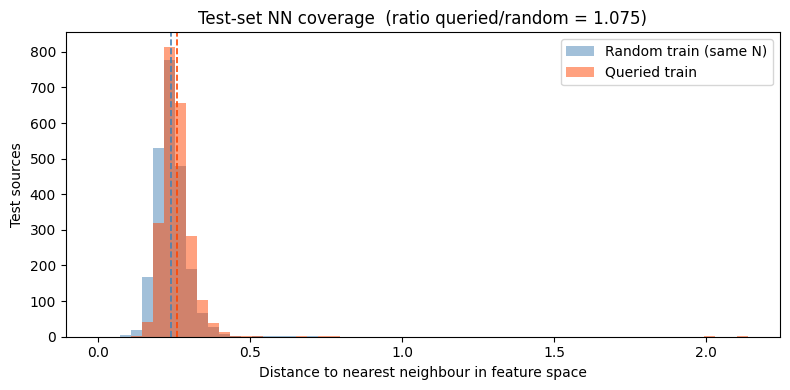

In [162]:
# ── Nearest-neighbour coverage: queried vs random train ────────────────────
_q_feat = features_train[_queried_mask].values
_r_feat = features_train[~_queried_mask].sample(
    n=_queried_mask.sum(), random_state=42).values
_t_feat = features_test.values

nn_q = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(_q_feat)
nn_r = NearestNeighbors(n_neighbors=1, algorithm='auto').fit(_r_feat)

d_q = nn_q.kneighbors(_t_feat)[0].ravel()
d_r = nn_r.kneighbors(_t_feat)[0].ravel()

ratio = d_q.mean() / d_r.mean()
print(f"Mean NN distance  queried: {d_q.mean():.4f}  random: {d_r.mean():.4f}  ratio: {ratio:.3f}")
print("(ratio > 1 → queried set covers test space worse than a random sample of same size)")

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, max(d_q.max(), d_r.max()), 60)
ax.hist(d_r, bins=bins, alpha=0.5, color='steelblue', label='Random train (same N)')
ax.hist(d_q, bins=bins, alpha=0.5, color='orangered', label='Queried train')
ax.axvline(d_q.mean(), color='orangered', linestyle='--', linewidth=1.2)
ax.axvline(d_r.mean(), color='steelblue', linestyle='--', linewidth=1.2)
ax.set_xlabel('Distance to nearest neighbour in feature space')
ax.set_ylabel('Test sources')
ax.set_title(f'Test-set NN coverage  (ratio queried/random = {ratio:.3f})')
ax.legend()
plt.tight_layout(); plt.show()

## Protege Sweep Results

Reads pre-computed Protege scores from `run_protege_sweep.py` output and plots recall curves for all matching runs, grouped by `f` and `sw`.

**Baselines** on the test set (complexity ranking, ellipses IsoForest, ellipses GP) are loaded from `baselines_{seed}.json` if available — computed by the single-run baseline cell above. Train-recall baselines (complexity and ellipses GP) are computed inline per subplot.

In [93]:
# Load / compute baselines for sweep section — reuses cell 28 result if available
# Cell 33 (de79ec13) loads its own per-seed baselines via _baselines_cache;
# this cell just ensures `baselines` is set for any other uses (e.g. cell 29).

if 'baselines' in dir() and baselines is not None:
    print(f"Reusing baselines from cell 28 (n_eval={baselines.get('n_eval', baselines.get('n_test', '?'))})")


Reusing baselines from cell 28 (n_eval=2279)


In [94]:
# ── Protege Sweep Config ──────────────────────────────────────────────────────
PROTEGE_SUFFIX  = ""    # output_suffix passed to run_protege_sweep.py
N_TRAIN_QUERIED = 600   # number of training samples used by Protege

LABELS_PATH = LABELS_NPY_PATH              # alias — defined in the Protege Integration Config cell

# ── Load all protege_scores parquet files ────────────────────────────────────
protege_results = []

_globs = [RUN_GLOB] if isinstance(RUN_GLOB, str) else RUN_GLOB
for rd in sorted({rd for g in _globs for rd in OUTPUTS_ROOT.glob(g)}):
    m = re.search(r'_f([\d.]+)_sw([\d.]+)_', rd.name)
    if not m:
        continue
    f_val  = float(m.group(1))
    sw_val = float(m.group(2))

    suffix    = f"_{PROTEGE_SUFFIX}" if PROTEGE_SUFFIX else ""
    scores_path  = rd / "protege" / f"protege_scores{suffix}.parquet"
    summary_path = rd / "protege" / f"protege_summary{suffix}.json"

    if not scores_path.exists():
        print(f"  ⚠ No protege scores found for {rd.name}, skipping.")
        continue

    active_output = pd.read_parquet(scores_path)

    if summary_path.exists():
        with open(summary_path) as fh:
            summary = json.load(fh)
        n_eval    = summary["n_eval"]
        n_pos     = summary["n_eval_positives"]
        auc       = summary.get("test_auc", summary.get("auc"))
        data_seed = summary.get("data_seed", 42)
    else:
        _labels_all  = np.load(LABELS_PATH)
        _test_idx    = np.load(rd / "data" / "test_idx.npy")
        _csv         = pd.read_csv(CSV_PATH)
        _src_names   = _csv.iloc[_test_idx]["Source_Name"].values
        _lsplit      = _labels_all[_test_idx]
        _ldf         = pd.DataFrame(_lsplit.astype(bool), columns=LABEL_COLS)
        _hl          = np.ones(len(_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _hl[_ldf[_cols].any(axis=1).values] = _sv
        _labels_df   = pd.DataFrame({"human_label": _hl}, index=_src_names)
        eval_mask = active_output["human_label"] == -2
        eval_srcs = active_output[eval_mask].index
        n_eval    = int(eval_mask.sum())
        n_pos     = int((_labels_df.loc[eval_srcs, "human_label"] >= POSITIVE_THRESHOLD).sum())
        auc       = None
        data_seed = 42

    protege_results.append(dict(
        name=rd.name, f=f_val, sw=sw_val,
        active_output=active_output,
        n_eval=n_eval, n_pos=n_pos, n_queried=N_TRAIN_QUERIED, auc=auc,
        data_seed=data_seed,
    ))
    print(f"  loaded {rd.name}  (f={f_val}, sw={sw_val})  "
          f"eval={n_eval}  pos={n_pos}  auc={auc:.4f}" if auc else
          f"  loaded {rd.name}  (f={f_val}, sw={sw_val})  eval={n_eval}  pos={n_pos}")

print(f"\nLoaded {len(protege_results)} Protege runs.")

# ── Helper: reconstruct recall curve from a GP-baseline parquet ──────────────
def _gp_recall_curve(parquet_path, test_idx_path):
    """Return (x, cum_recall, auc) for a GP-baseline parquet produced by
    train_anomaly_baselines.py, using that run's own test split."""
    _df     = pd.read_parquet(parquet_path)
    _test   = _df[_df["human_label"] == -2.0]
    _tidx   = np.load(test_idx_path)
    _lraw   = np.load(LABELS_PATH)[_tidx]
    _ldf    = pd.DataFrame(_lraw.astype(bool), columns=LABEL_COLS)
    _hl     = np.ones(len(_ldf), dtype=int)
    for _sv, _cols in reversed(TIERS):
        _hl[_ldf[_cols].any(axis=1).values] = _sv
    _src    = pd.read_csv(CSV_PATH).iloc[_tidx]["Source_Name"].values
    _tl     = pd.Series(_hl, index=_src)
    _ranked = _test["trained_score"].sort_values(ascending=False)
    _pos    = (_tl.loc[_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _cum    = np.cumsum(_pos)
    _n, _p  = len(_cum), int(_pos.sum())
    _x      = np.arange(1, _n + 1)
    _auc    = float(np.trapezoid(_cum, _x) / (_n * _p)) if _p > 0 else 0.0
    return _x, _cum, _auc

# ── Recall curves — one subplot per f value ──────────────────────────────────
f_vals_p  = sorted(set(r["f"]  for r in protege_results))
sw_vals_p = sorted(set(r["sw"] for r in protege_results))

try:
    _ = sw_color
except NameError:
    cmap_p   = plt.cm.viridis(np.linspace(0.15, 0.85, len(sw_vals_p)))
    sw_color = {sw: cmap_p[i] for i, sw in enumerate(sw_vals_p)}

ncols = min(len(f_vals_p), 3)
nrows = (len(f_vals_p) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                          figsize=(ncols * 5.5, nrows * 4.5),
                          sharey=False)
axes = np.array(axes).reshape(nrows, ncols)

_baselines_cache    = {}   # simple direct-ranking baselines, keyed by data_seed
_gp_baselines_cache = {}   # GP baselines from train_anomaly_baselines.py, keyed by data_seed

for ax_idx, f_val in enumerate(f_vals_p):
    ax = axes[ax_idx // ncols, ax_idx % ncols]
    group = [r for r in protege_results if r["f"] == f_val]

    for r in sorted(group, key=lambda x: x["sw"]):
        ao          = r["active_output"]
        eval_ao     = ao[ao["human_label"] == -2]
        n_eval      = r["n_eval"]
        n_pos       = r["n_pos"]
        ranked_eval = eval_ao.sort_values("trained_score", ascending=False)

        _labels_all  = np.load(LABELS_PATH)
        _test_idx    = np.load(OUTPUTS_ROOT / r["name"] / "data" / "test_idx.npy")
        _src_names   = pd.read_csv(CSV_PATH).iloc[_test_idx]["Source_Name"].values
        _ldf         = pd.DataFrame(_labels_all[_test_idx].astype(bool), columns=LABEL_COLS)
        _hl          = np.ones(len(_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _hl[_ldf[_cols].any(axis=1).values] = _sv
        _true_labels = pd.Series(_hl, index=_src_names)

        binary_eval = (_true_labels.loc[ranked_eval.index] >= POSITIVE_THRESHOLD).astype(int).values
        cumulative  = np.cumsum(binary_eval)
        x           = np.arange(1, n_eval + 1)

        auc_str = f"  AUC={r['auc']:.3f}" if r["auc"] is not None else ""
        ax.plot(x, cumulative,
                color=sw_color[r["sw"]], linewidth=1.8,
                label=f"sw={r['sw']}{auc_str}")
        ax.plot(x, x * (n_pos / n_eval), color=sw_color[r["sw"]],
                linestyle="--", linewidth=0.9, alpha=0.5)

    _dseed = group[0]["data_seed"]

    # ── Simple baselines (direct ranking, paper methodology) ─────────────────
    if _dseed not in _baselines_cache:
        _bp = OUTPUTS_ROOT / f"baselines_{_dseed}.json"
        _baselines_cache[_dseed] = json.load(open(_bp)) if _bp.exists() else None
    _bl = _baselines_cache[_dseed]
    if _bl is not None:
        ax.plot(_bl["complexity"]["x"], _bl["complexity"]["recall"],
                color="grey", linewidth=1.0, linestyle="--",
                label=f"Complexity (AUC={_bl['complexity']['auc']:.3f})")
        ax.plot(_bl["ellipses"]["x"], _bl["ellipses"]["recall"],
                color="grey", linewidth=1.0, linestyle=":",
                label=f"Ellipses (IsoForest) (AUC={_bl['ellipses']['auc']:.3f})")

    # ── GP baselines (train_anomaly_baselines.py) ─────────────────────────────
    if _dseed not in _gp_baselines_cache:
        _gp_dir = OUTPUTS_ROOT / f"anomaly_baseline_seed{_dseed}"
        _gp = {}
        if _gp_dir.exists():
            _gp_tidx_path = _gp_dir / "data" / "test_idx.npy"
            # Complexity GP
            _comp_p = _gp_dir / "complexity" / "protege_scores.parquet"
            if _comp_p.exists() and _gp_tidx_path.exists():
                try:
                    _gp["complexity_gp"] = _gp_recall_curve(_comp_p, _gp_tidx_path)
                except Exception:
                    pass
            # Ellipses GP — mean over all runs
            _ell_runs = sorted((_gp_dir / "ellipses").glob("run_*/protege_scores.parquet"))
            if _ell_runs and _gp_tidx_path.exists():
                try:
                    _tidx_e  = np.load(_gp_tidx_path)
                    _lraw_e  = np.load(LABELS_PATH)[_tidx_e]
                    _ldf_e   = pd.DataFrame(_lraw_e.astype(bool), columns=LABEL_COLS)
                    _hl_e    = np.ones(len(_ldf_e), dtype=int)
                    for _sv, _cols in reversed(TIERS):
                        _hl_e[_ldf_e[_cols].any(axis=1).values] = _sv
                    _n_pos_e = int((_hl_e >= POSITIVE_THRESHOLD).sum())

                    _curves = []
                    for _erp in _ell_runs:
                        _, _c, _ = _gp_recall_curve(_erp, _gp_tidx_path)
                        _curves.append(_c)
                    _min_len = min(len(c) for c in _curves)
                    _mean_c  = np.array([c[:_min_len] for c in _curves]).mean(axis=0)
                    _x_e     = np.arange(1, _min_len + 1)
                    _auc_e   = float(np.trapezoid(_mean_c, _x_e) / (_min_len * _n_pos_e)) if _n_pos_e > 0 else 0.0
                    _gp["ellipses_gp"] = (_x_e, _mean_c, _auc_e)
                except Exception:
                    pass
        _gp_baselines_cache[_dseed] = _gp if _gp else None
    _gp_bl = _gp_baselines_cache[_dseed]
    if _gp_bl:
        if "complexity_gp" in _gp_bl:
            _gx, _gc, _ga = _gp_bl["complexity_gp"]
            ax.plot(_gx, _gc, color="tab:purple", linewidth=1.0, linestyle="--",
                    label=f"Complexity GP (AUC={_ga:.3f})")
        if "ellipses_gp" in _gp_bl:
            _ex, _ec, _ea = _gp_bl["ellipses_gp"]
            ax.plot(_ex, _ec, color="tab:purple", linewidth=1.0, linestyle=":",
                    label=f"Ellipses GP (AUC={_ea:.3f})")

    ax.axvline(x=r["n_queried"], color="grey", linestyle=":",
               linewidth=1.1, alpha=0.7, label=f"N queried={r['n_queried']}")
    ax.set_title(f"f={f_val}  ({n_eval} eval, {n_pos} positives)", fontsize=11)
    ax.set_xlabel("Eval sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found")
    ax.legend(fontsize=8, framealpha=0.8, loc="lower right")
    ax.grid(True, alpha=0.3)

for idx in range(len(f_vals_p), nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle("Protege recall curves by f and sw", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── AUC summary table ────────────────────────────────────────────────────────
if any(r["auc"] is not None for r in protege_results):
    print("\nAUC summary (higher = better):")
    print(f"{'run_name':<45}  {'f':>5}  {'sw':>5}  {'AUC':>7}  {'eval':>6}  {'pos':>5}")
    print("-" * 80)
    for r in sorted(protege_results, key=lambda x: -(x["auc"] or 0)):
        print(f"{r['name']:<45}  {r['f']:>5.2f}  {r['sw']:>5.1f}  "
              f"{r['auc']:>7.4f}  {r['n_eval']:>6}  {r['n_pos']:>5}")

# ── Train recall curves (queried sources) — one subplot per f value ──────────
_csv_all_t     = pd.read_csv(CSV_PATH)
_name_to_idx_t = {name: i for i, name in enumerate(_csv_all_t["Source_Name"].values)}
_lraw_all_t    = np.load(LABELS_PATH)

fig_t, axes_t = plt.subplots(nrows, ncols,
                              figsize=(ncols * 5.5, nrows * 4.5),
                              sharey=False)
axes_t = np.array(axes_t).reshape(nrows, ncols)

for ax_idx, f_val in enumerate(f_vals_p):
    ax    = axes_t[ax_idx // ncols, ax_idx % ncols]
    group = [r for r in protege_results if r["f"] == f_val]

    _n_queried_last = _n_pos_last = 0
    for r in sorted(group, key=lambda x: x["sw"]):
        ao            = r["active_output"]
        train_queried = ao[ao["human_label"] > 0]  # labeled (queried) train sources only

        _tq_global = np.array([_name_to_idx_t[n] for n in train_queried.index])
        _tq_lraw   = _lraw_all_t[_tq_global]
        _tq_ldf    = pd.DataFrame(_tq_lraw.astype(bool), columns=LABEL_COLS)
        _hl_tq     = np.ones(len(_tq_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _hl_tq[_tq_ldf[_cols].any(axis=1).values] = _sv
        _true_train = pd.Series(_hl_tq, index=train_queried.index)

        n_q   = len(train_queried)
        n_p_t = int((_true_train >= POSITIVE_THRESHOLD).sum())
        ranked_t = train_queried.sort_values("trained_score", ascending=False)
        binary_t = (_true_train.loc[ranked_t.index] >= POSITIVE_THRESHOLD).astype(int).values
        cum_t    = np.cumsum(binary_t)
        x_t      = np.arange(1, n_q + 1)
        auc_t    = float(np.trapz(cum_t, x_t) / (n_q * n_p_t)) if n_p_t > 0 else 0.0

        ax.plot(x_t, cum_t, color=sw_color[r["sw"]], linewidth=1.8,
                label=f"sw={r['sw']}  AUC={auc_t:.3f}")
        ax.plot(x_t, x_t * (n_p_t / n_q),
                color=sw_color[r["sw"]], linestyle="--", linewidth=0.9, alpha=0.5)
        _n_queried_last, _n_pos_last = n_q, n_p_t

    _dseed = group[0]["data_seed"]

    # ── Complexity baseline on queried train ──────────────────────────────────
    _csv_fc_all   = pd.read_csv(CSV_PATH).set_index("Source_Name")["featurecount"]
    _fc_q         = _csv_fc_all.loc[train_queried.index].values
    _comp_order_q = np.argsort(_fc_q)[::-1]
    _cum_comp_q   = np.cumsum((_true_train.values[_comp_order_q] >= POSITIVE_THRESHOLD).astype(int))
    ax.plot(x_t, _cum_comp_q, color="grey", linewidth=1.0, linestyle="--",
            label=f"Complexity (AUC={np.trapz(_cum_comp_q, x_t) / (n_q * n_p_t):.3f})")

    # ── Ellipses GP baseline on queried train ─────────────────────────────────
    _gp_ell_dir = OUTPUTS_ROOT / f"anomaly_baseline_seed{_dseed}" / "ellipses"
    if _gp_ell_dir.exists():
        _gp_q_curves = []
        for _rp in sorted(_gp_ell_dir.glob("run_*/protege_scores.parquet")):
            _df_gp  = pd.read_parquet(_rp)
            _tr_gp  = _df_gp[_df_gp["human_label"] != -2.0]
            _common = [n for n in train_queried.index if n in _tr_gp.index]
            if len(_common) < 5: continue
            _gp_ranked = _tr_gp.loc[_common].sort_values("trained_score", ascending=False)
            _gp_tl     = _true_train.loc[_gp_ranked.index]
            _gp_q_curves.append(np.cumsum((_gp_tl >= POSITIVE_THRESHOLD).astype(int).values))
        if _gp_q_curves:
            _ml = min(len(c) for c in _gp_q_curves)
            _mc = np.array([c[:_ml] for c in _gp_q_curves]).mean(axis=0)
            _xg = np.arange(1, _ml + 1)
            _ag = float(np.trapz(_mc, _xg) / (_ml * n_p_t)) if n_p_t > 0 else 0.0
            ax.plot(_xg, _mc, color="grey", linewidth=1.0, linestyle=":",
                    label=f"Ellipses GP (AUC={_ag:.3f})")

    ax.set_title(f"f={f_val}  ({_n_queried_last} queried, {_n_pos_last} positives)", fontsize=11)
    ax.set_xlabel("Queried train sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found")
    ax.legend(fontsize=8, framealpha=0.8, loc="lower right")
    ax.grid(True, alpha=0.3)

for idx in range(len(f_vals_p), nrows * ncols):
    axes_t[idx // ncols, idx % ncols].set_visible(False)

fig_t.suptitle("Protege train recall curves by f and sw", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0.2_sw10_20260605_1135, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0.2_sw1_20260605_1011, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0.2_sw3_20260605_1051, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0.5_sw0.05_20260606_1500, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0.5_sw10_20260606_1619, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0.5_sw1_20260605_1218, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0.5_sw3_20260606_1539, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b256_f0_sw1_20260606_1441, skipping.
  ⚠ No protege scores found for run_enb0_mlp_pond_lrconst_wd1e-4_lfull_e300_b

ZeroDivisionError: integer division or modulo by zero

Test eval set size: 2279
Positives in shared set: 383 / 2279


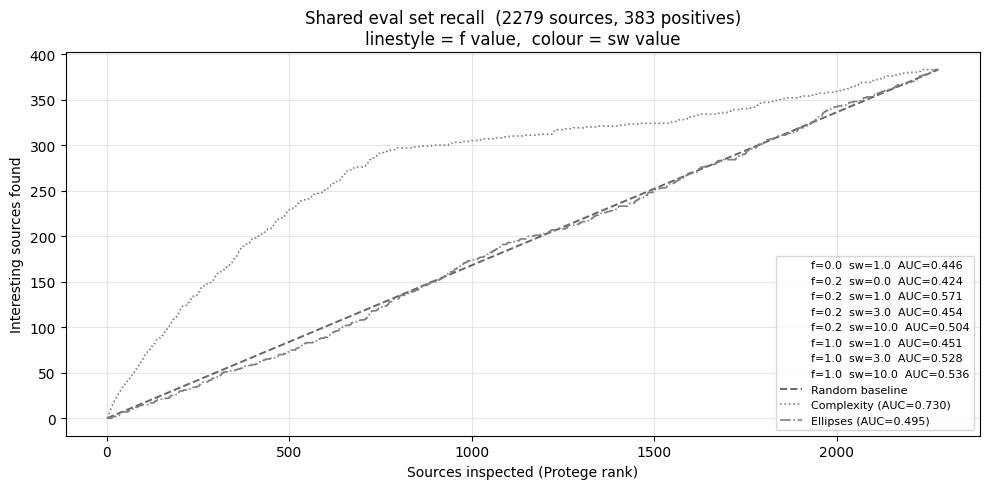


Shared eval set AUC ranking  (2279 sources, 383 positives):
run_name                                           f     sw      AUC
-----------------------------------------------------------------
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f0.2_sw1_20260528_1258   0.20    1.0   0.5712
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f1_sw10_20260528_1546   1.00   10.0   0.5362
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f1_sw3_20260528_1507   1.00    3.0   0.5281
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f0.2_sw10_20260528_1812   0.20   10.0   0.5041
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f0.2_sw3_20260528_1339   0.20    3.0   0.4542
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f1_sw1_20260528_1428   1.00    1.0   0.4509
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f0_sw1_20260528_1040   0.00    1.0   0.4462
run_enb0_prepca_pond_lrconst_wd1e-4_lfull_e300_b256_f0.2_sw0_20260528_1218   0.20    0.0   0.4243


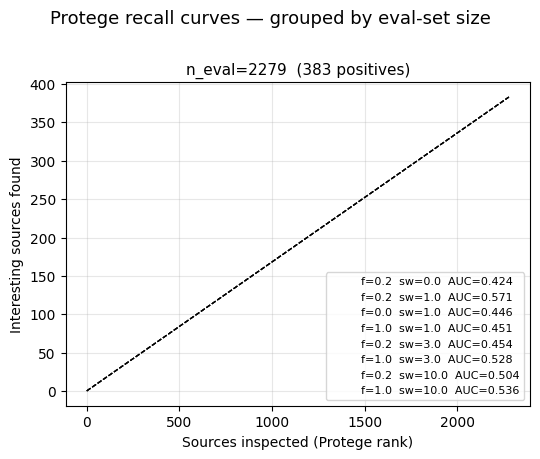

In [ ]:
# ── Shared eval set + Superfigure (grouped by eval-set size) ─────────────────
_labels_all = np.load(LABELS_PATH)
_csv_df     = pd.read_csv(CSV_PATH)

# ── Part 1: all runs on a single shared-eval-set plot ────────────────────────
r0             = protege_results[0]
ao0            = r0["active_output"]
shared_sources = sorted(ao0[ao0["human_label"] == -2].index.tolist())
print(f"Test eval set size: {len(shared_sources)}")

_test_idx  = np.load(OUTPUTS_ROOT / r0["name"] / "data" / "test_idx.npy")
_src_names = _csv_df.iloc[_test_idx]["Source_Name"].values
_ldf       = pd.DataFrame(_labels_all[_test_idx].astype(bool), columns=LABEL_COLS)
_hl        = np.ones(len(_ldf), dtype=int)
for _sv, _cols in reversed(TIERS):
    _hl[_ldf[_cols].any(axis=1).values] = _sv
true_labels_shared = pd.Series(_hl, index=_src_names)

if len(shared_sources) == 0:
    print("No shared sources — cannot plot.")
else:
    shared_true  = (true_labels_shared.loc[shared_sources] >= POSITIVE_THRESHOLD).astype(int)
    n_shared     = len(shared_sources)
    n_pos_shared = int(shared_true.sum())
    print(f"Positives in shared set: {n_pos_shared} / {n_shared}")

    f_vals_present = sorted(set(r["f"] for r in protege_results))
    linestyles     = ["-", "--", "-.", ":"]
    f_ls           = {f: linestyles[i % len(linestyles)] for i, f in enumerate(f_vals_present)}

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(1, n_shared + 1)

    _shared_aucs = []
    for r in sorted(protege_results, key=lambda r: (r["f"], r["sw"])):
        scores = r["active_output"].loc[shared_sources, "trained_score"]
        ranked = scores.sort_values(ascending=False).index
        cum    = np.cumsum(shared_true.loc[ranked].values)
        auc    = float(np.trapz(cum, x) / (n_shared * n_pos_shared)) if n_pos_shared > 0 else 0.0
        _shared_aucs.append(dict(name=r["name"], f=r["f"], sw=r["sw"], auc=auc))
        ax.plot(x, cum, color=sw_color[r["sw"]], linestyle=f_ls[r["f"]],
                linewidth=1.8, label=f"f={r['f']}  sw={r['sw']}  AUC={auc:.3f}")

    ax.plot(x, x * (n_pos_shared / n_shared), "k--", linewidth=1.4, alpha=0.6,
            label="Random baseline")
    if baselines is not None:
        ax.plot(baselines["complexity"]["x"], baselines["complexity"]["recall"],
                color="grey", linewidth=1.2, linestyle=":",
                label=f"Complexity (AUC={baselines['complexity']['auc']:.3f})")
        ax.plot(baselines["ellipses"]["x"], baselines["ellipses"]["recall"],
                color="grey", linewidth=1.2, linestyle="-.",
                label=f"Ellipses (AUC={baselines['ellipses']['auc']:.3f})")

    ax.set_xlabel("Sources inspected (Protege rank)")
    ax.set_ylabel("Interesting sources found")
    ax.set_title(f"Shared eval set recall  ({n_shared} sources, {n_pos_shared} positives)\n"
                 f"linestyle = f value,  colour = sw value")
    ax.legend(fontsize=8, framealpha=0.8, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nShared eval set AUC ranking  ({n_shared} sources, {n_pos_shared} positives):")
    print(f"{'run_name':<45}  {'f':>5}  {'sw':>5}  {'AUC':>7}")
    print("-" * 65)
    for _r in sorted(_shared_aucs, key=lambda r: -r["auc"]):
        print(f"{_r['name']:<45}  {_r['f']:>5.2f}  {_r['sw']:>5.1f}  {_r['auc']:>7.4f}")

# ── Part 2: subplots grouped by eval-set size ─────────────────────────────────
groups = defaultdict(list)
for r in protege_results:
    groups[r["n_eval"]].append(r)

eval_sizes = sorted(groups.keys(), reverse=True)
ncols = min(len(eval_sizes), 3)
nrows = (len(eval_sizes) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 5.5, nrows * 4.5),
                         sharey=False)
axes = np.array(axes).reshape(nrows, ncols)

for ax_idx, n_eval in enumerate(eval_sizes):
    ax    = axes[ax_idx // ncols, ax_idx % ncols]
    group = sorted(groups[n_eval], key=lambda r: r["sw"])

    for r in group:
        eval_ao     = r["active_output"]
        eval_ao     = eval_ao[eval_ao["human_label"] == -2].sort_values("trained_score", ascending=False)
        _test_idx   = np.load(OUTPUTS_ROOT / r["name"] / "data" / "test_idx.npy")
        _src_names  = _csv_df.iloc[_test_idx]["Source_Name"].values
        _ldf        = pd.DataFrame(_labels_all[_test_idx].astype(bool), columns=LABEL_COLS)
        _hl         = np.ones(len(_ldf), dtype=int)
        for _sv, _cols in reversed(TIERS):
            _hl[_ldf[_cols].any(axis=1).values] = _sv
        true_labels = pd.Series(_hl, index=_src_names)

        cum     = np.cumsum((true_labels.loc[eval_ao.index] >= POSITIVE_THRESHOLD).astype(int).values)
        x       = np.arange(1, n_eval + 1)
        n_pos   = r["n_pos"]
        color   = sw_color[r["sw"]]
        auc_str = f"  AUC={r['auc']:.3f}" if r["auc"] is not None else ""
        ax.plot(x, cum, color=color, linewidth=1.8, label=f"f={r['f']}  sw={r['sw']}{auc_str}")
        ax.plot(x, x * (n_pos / n_eval), color=color, linestyle="--", linewidth=0.9, alpha=0.45)

    ax.set_title(f"n_eval={n_eval}  ({n_pos} positives)", fontsize=11)
    ax.set_xlabel("Sources inspected (Protege rank)")
    ax.set_ylabel("Interesting sources found")
    ax.legend(fontsize=8, framealpha=0.8, loc="lower right")
    ax.grid(True, alpha=0.3)

for idx in range(len(eval_sizes), nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle("Protege recall curves — grouped by eval-set size", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## Interactive Protege Fine-Tuning

Select one run from the sweep results, warm-start the GP from its existing labels,
and continue active learning interactively. The final recall curve shows both the
original sweep result and the interactively fine-tuned result on their respective
evaluation sets (sources never queried by either phase).

In [ ]:
# ── Select which run to fine-tune ────────────────────────────────────────────
FINETUNE_RUN_NAME = "run_no_val_run_f0.5_sw3_20260521_1904"  # edit to pick a run (f≠1)
PROTEGE_SUFFIX    = ""   # must match the suffix used in run_protege_sweep.py

# ── Load the selected run's sweep results ────────────────────────────────────
_ft_run = next((r for r in protege_results if r["name"] == FINETUNE_RUN_NAME), None)
assert _ft_run is not None, (
    f"Run '{FINETUNE_RUN_NAME}' not found in protege_results. "
    f"Available: {[r['name'] for r in protege_results]}"
)

_suffix      = f"_{PROTEGE_SUFFIX}" if PROTEGE_SUFFIX else ""
_scores_path = OUTPUTS_ROOT / FINETUNE_RUN_NAME / "protege" / f"protege_scores{_suffix}.parquet"
_sweep_ao    = pd.read_parquet(_scores_path)

# ── Reconstruct features_pca (mirrors train_protege_list.py logic) ────────────
_data_dir   = OUTPUTS_ROOT / FINETUNE_RUN_NAME / "data"
_lab_idx    = np.load(_data_dir / "labelled_train_idx.npy")
_unlab_idx  = np.load(_data_dir / "unlabelled_train_idx.npy")

_lab_proj        = np.load(_data_dir / "labelled_train_projections.npy")
_unlab_proj_path = _data_dir / "unlabelled_train_projections.npy"
if _unlab_proj_path.exists() and len(_lab_idx) > 0 and len(_unlab_idx) > 0:
    _unlab_proj = np.load(_unlab_proj_path)
    _all_proj   = np.concatenate([_lab_proj, _unlab_proj], axis=0)
    _all_idx    = np.concatenate([_lab_idx, _unlab_idx])
elif len(_lab_idx) == 0:   # f=0
    _all_proj = _lab_proj
    _all_idx  = _unlab_idx
else:                       # f=1
    _all_proj = _lab_proj
    _all_idx  = _lab_idx

_csv        = pd.read_csv(CSV_PATH)
_src_names  = _csv.iloc[_all_idx]["Source_Name"].values

_proj_scaled = StandardScaler().fit_transform(_all_proj)
_pca_model   = PCA(n_components=0.95, svd_solver="full")
_proj_pca    = _pca_model.fit_transform(_proj_scaled)
ft_features  = pd.DataFrame(_proj_pca, index=_src_names)
print(f"Features: {ft_features.shape}")

# ── Reconstruct true labels ───────────────────────────────────────────────────
_labels_all  = np.load(LABELS_PATH)
_ldf         = pd.DataFrame(_labels_all[_all_idx].astype(bool), columns=LABEL_COLS)
_hl          = np.ones(len(_ldf), dtype=int)
for _sv, _cols in reversed(TIERS):
    _hl[_ldf[_cols].any(axis=1).values] = _sv
ft_true_labels = pd.Series(_hl, index=_src_names)

# ── Record original sweep eval set (human_label == -1 in parquet) ────────────
_sweep_eval_mask = _sweep_ao["human_label"] == -1
_sweep_eval_srcs = set(_sweep_ao[_sweep_eval_mask].index)
n_sweep_eval     = len(_sweep_eval_srcs)
n_sweep_pos      = int((ft_true_labels.loc[list(_sweep_eval_srcs)] >= POSITIVE_THRESHOLD).sum())
print(f"Sweep eval set: {n_sweep_eval} sources, {n_sweep_pos} positives")

# ── Images for interactive display ───────────────────────────────────────────
_images_all    = np.load(IMAGES_PATH)
_ft_images     = _images_all[_all_idx]
_ft_src_to_pos = {src: i for i, src in enumerate(_src_names)}


In [ ]:
# ── Interactive fine-tuning widget ───────────────────────────────────────────
def _ft_get_image(src):
    i = _ft_src_to_pos.get(src)
    if i is None:
        return None
    img = _ft_images[i].astype(float)
    return img[0] if img.ndim == 3 else img

def _ft_show_batch(sources, scores_df):
    n = len(sources)
    ncols = min(n, 5)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 2.8, nrows * 2.8 + 0.4))
    axes = np.array(axes).reshape(nrows, ncols)
    for idx, src in enumerate(sources):
        ax = axes[idx // ncols, idx % ncols]
        img = _ft_get_image(src)
        if img is not None:
            vmax = 0.9 * float(img.max())
            scaled = np.arcsinh(np.clip(img, 0, vmax) / (0.1 * vmax + 1e-8))
            ax.imshow(scaled, cmap="inferno", origin="lower")
        else:
            ax.set_facecolor("#222")
            ax.text(0.5, 0.5, "no image", color="white",
                    ha="center", va="center", transform=ax.transAxes)
        acq = scores_df.loc[src, "acquisition"] if "acquisition" in scores_df.columns else float("nan")
        true_score = ft_true_labels.get(src, "?")
        ax.set_title(f"{src[-16:]}\nacq={acq:.3f} | true={true_score}",
                     fontsize=6, pad=2)
        ax.axis("off")
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis("off")
    plt.tight_layout()
    plt.show()

# Widget state
_ft_state     = {"iter": 0}
_ft_inputs    = []
_ft_out_area  = widgets.Output()
_ft_submit    = widgets.Button(description="Submit scores", button_style="success")
_ft_continue  = widgets.Button(description="Next batch →",  button_style="primary")
_ft_stop      = widgets.Button(description="Stop & plot",   button_style="danger")

def _ft_load_batch():
    ft_qs.sort_values("acquisition", ascending=False, inplace=True)
    _candidates = ft_qs[
        (ft_qs.human_label == -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ]
    _batch = list(_candidates.index[:STEPS_PER_ITER])
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        clear_output(wait=True)
        print(f"=== Iteration {_ft_state['iter']} | "
              f"total labelled {n_done} ===")
        _ft_show_batch(_batch, ft_qs)
        print(f"\nEnter scores 1–5 (left→right, top→bottom):")
        for i, src in enumerate(_batch):
            print(f"  [{i}] {src[-22:]}")

    _ft_inputs.clear()
    for src in _batch:
        w = widgets.IntSlider(
            value=2, min=1, max=5, step=1,
            description=f"{src[-18:]}",
            style={"description_width": "200px"},
            layout=widgets.Layout(width="500px"),
        )
        _ft_inputs.append((src, w))

    display(widgets.VBox([w for _, w in _ft_inputs]),
            widgets.HBox([_ft_submit, _ft_stop]))

def _ft_on_submit(b):
    for src, w in _ft_inputs:
        ft_qs.loc[src, "human_label"] = w.value
    _fw = _ft_pipeline.combine_data_frames(ft_features, ft_qs)
    _out = _ft_pipeline.run(_fw)
    ft_qs["trained_score"] = _out["trained_score"]
    ft_qs["acquisition"]   = _out["acquisition"]
    _ft_state["iter"] += 1
    n_done = int((ft_qs.human_label != -1).sum())
    with _ft_out_area:
        print(f"✓ Submitted. Total labelled: {n_done}")
    display(widgets.HBox([_ft_continue, _ft_stop]))

def _ft_on_continue(b):
    _ft_load_batch()

def _ft_on_stop(b):
    _ft_finish()

def _ft_finish():
    _save_path = _ft_protege_dir / "protege_scores_interactive.parquet"
    ft_qs.to_parquet(_save_path)
    print(f"Saved interactive scores to {_save_path}")
    _ft_plot_comparison()

def _ft_plot_comparison():
    _sw_ranked = _sweep_ao[_sweep_ao.index.isin(_sweep_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _sw_binary = (ft_true_labels.loc[_sw_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _sw_cum    = np.cumsum(_sw_binary)
    _sw_x      = np.arange(1, len(_sw_ranked) + 1)
    _sw_rand   = _sw_x * (n_sweep_pos / len(_sw_ranked))

    _newly_queried = set(ft_qs[
        (ft_qs.human_label != -1) &
        (ft_qs.index.isin(_sweep_eval_srcs))
    ].index)
    _ft_eval_srcs = _sweep_eval_srcs - _newly_queried
    n_ft_eval     = len(_ft_eval_srcs)
    n_ft_pos      = int((ft_true_labels.loc[list(_ft_eval_srcs)] >= POSITIVE_THRESHOLD).sum())

    _ft_ranked = ft_qs[ft_qs.index.isin(_ft_eval_srcs)].sort_values(
        "trained_score", ascending=False)
    _ft_binary = (ft_true_labels.loc[_ft_ranked.index] >= POSITIVE_THRESHOLD).astype(int).values
    _ft_cum    = np.cumsum(_ft_binary)
    _ft_x      = np.arange(1, n_ft_eval + 1)
    _ft_rand   = _ft_x * (n_ft_pos / n_ft_eval)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(_sw_x,  _sw_cum,  color="steelblue",  linewidth=2,
            label=f"Sweep  (eval={n_sweep_eval}, pos={n_sweep_pos})")
    ax.plot(_sw_x,  _sw_rand, color="steelblue",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (sweep)")
    ax.plot(_ft_x,  _ft_cum,  color="darkorange",  linewidth=2,
            label=f"Interactive  (eval={n_ft_eval}, pos={n_ft_pos})")
    ax.plot(_ft_x,  _ft_rand, color="darkorange",  linewidth=1,
            linestyle="--", alpha=0.5, label="Random (interactive)")
    ax.axvline(x=int((_sweep_ao.human_label != -1).sum()),
               color="grey", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Sweep N queried")
    ax.axvline(x=int((ft_qs.human_label != -1).sum()),
               color="sienna", linestyle=":", linewidth=1.2, alpha=0.7,
               label=f"Interactive N queried")
    ax.set_xlabel("Eval sources inspected (ranked by Protege score)")
    ax.set_ylabel("Interesting sources found")
    ax.set_title(f"Protege recall — {FINETUNE_RUN_NAME}\n"
                 f"Sweep vs interactive fine-tuning")
    ax.legend(fontsize=9, framealpha=0.85, loc="lower right")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

_ft_submit.on_click(_ft_on_submit)
_ft_continue.on_click(_ft_on_continue)
_ft_stop.on_click(_ft_on_stop)

display(_ft_out_area)
_ft_load_batch()